## Taller de Programación en Python
### Profesor: Lucas Gómez Tobón

## Sesión 7. Introducción a la visualización con pandas, matplotlib y seaborn

En el análisis de datos, la forma en que estructuramos nuestra información es fundamental. Un conjunto de datos bien organizado facilita enormemente la manipulación, visualización y modelado. Uno de los conceptos más influyentes en la estructuración de datos es el de **"Tidy Data"** (Datos Ordenados).

### ¿Qué es un "Tidy Dataset"?

El concepto de "Tidy Data", popularizado por Hadley Wickham, propone un estándar para organizar datos tabulares. La idea es simple pero poderosa. Un conjunto de datos se considera "tidy" si cumple con las siguientes tres reglas:

1.  **Cada variable forma una columna.**
2.  **Cada observación forma una fila.**
3.  **Cada tipo de unidad observacional forma una tabla.**

Pensemos en un experimento simple donde medimos el peso de dos personas, Juan y Ana, en dos momentos diferentes del año.

#### Ejemplo de un dataset "untidy" (desordenado)

| Nombre | Peso (Enero) | Peso (Junio) |
| :----- | :----------- | :----------- |
| Juan   | 80           | 82           |
| Ana    | 65           | 64           |

A primera vista, esta tabla parece lógica. Sin embargo, no sigue las reglas de "tidy data":
-   Las columnas "Peso (Enero)" y "Peso (Junio)" no son variables únicas; son combinaciones de la variable "peso" y la variable "mes".
-   Tenemos dos observaciones por persona, pero están distribuidas en una sola fila.

#### Ejemplo de un dataset "tidy" (ordenado)

| Nombre | Mes   | Peso |
| :----- | :---- | :--- |
| Juan   | Enero | 80   |
| Juan   | Junio | 82   |
| Ana    | Enero | 65   |
| Ana    | Junio | 64   |

Esta segunda estructura es "tidy". ¿Por qué?
-   **Cada columna es una variable:** `Nombre`, `Mes`, `Peso`.
-   **Cada fila es una observación:** Una medición de peso para una persona específica en un mes específico.

Trabajar con este formato en `pandas` es mucho más eficiente para agrupar, filtrar y visualizar datos.

### Formato Ancho (Wide) vs. Formato Largo (Long)

Los ejemplos anteriores ilustran dos formatos comunes para almacenar datos: ancho y largo.

#### Wide Dataframe (Formato Ancho)

El formato ancho es el que vimos en nuestro primer ejemplo "untidy". Se caracteriza por tener múltiples columnas que representan diferentes mediciones de una misma variable a lo largo del tiempo o bajo diferentes condiciones. Es un formato muy intuitivo para la entrada de datos manual, pero es poco práctico para el análisis computacional.

**Características:**
-   Cada fila representa un sujeto o ítem único.
-   Las observaciones repetidas para ese sujeto se representan con nuevas columnas.

| Nombre | Peso (Enero) | Peso (Junio) |
| :----- | :----------- | :----------- |
| Juan   | 80           | 82           |
| Ana    | 65           | 64           |

#### Long Dataframe (Formato Largo)

El formato largo es el que corresponde al "tidy dataset". Cada fila es una única observación, lo que puede hacer que el mismo sujeto (como "Juan") aparezca en múltiples filas.

**Características:**
-   Una columna contiene los valores de la variable medida (ej. `Peso`).
-   Otra columna indica el contexto de esa medición (ej. `Mes`).

| Nombre | Mes   | Peso |
| :----- | :---- | :--- |
| Juan   | Enero | 80   |
| Juan   | Junio | 82   |
| Ana    | Enero | 65   |
| Ana    | Junio | 64   |

In [1]:
import pandas as pd

# Veamos un ejemplo práctico de un df untidy
untidy_gapminder = pd.read_excel('../Datos/untidy_gapminder.xlsx')
untidy_gapminder

,country,variable,1952,1957,1962,1967,1972,1977,1982,1987,1992,1997,2002,2007
0,Afghanistan,gdpPercap,779.445314,820.853030,853.100710,836.197138,739.981106,786.113360,978.011439,852.395945,649.341395,635.341351,726.734055,974.580338
1,Afghanistan,lifeExp,28.801000,30.332000,31.997000,34.020000,36.088000,38.438000,39.854000,40.822000,41.674000,41.763000,42.129000,43.828000
2,Albania,gdpPercap,1601.056136,1942.284244,2312.888958,2760.196931,3313.422188,3533.003910,3630.880722,3738.932735,2497.437901,3193.054604,4604.211737,5937.029526
3,Albania,lifeExp,55.230000,59.280000,64.820000,66.220000,67.690000,68.930000,70.420000,72.000000,71.581000,72.950000,75.651000,76.423000
4,Algeria,gdpPercap,2449.008185,3013.976023,2550.816880,3246.991771,4182.663766,4910.416756,5745.160213,5681.358539,5023.216647,4797.295051,5288.040382,6223.367465
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
279,"Yemen, Rep.",lifeExp,32.548000,33.970000,35.180000,36.984000,39.848000,44.175000,49.113000,52.922000,55.599000,58.020000,60.308000,62.698000
280,Zambia,gdpPercap,1147.388831,1311.956766,1452.725766,1777.077318,1773.498265,1588.688299,1408.678565,1213.315116,1210.884633,1071.353818,1071.613938,1271.211593
281,Zambia,lifeExp,42.038000,44.077000,46.023000,47.768000,50.107000,51.386000,51.821000,50.821000,46.100000,40.238000,39.193000,42.384000
282,Zimbabwe,gdpPercap,406.884115,518.764268,527.272182,569.795071,799.362176,685.587682,788.855041,706.157306,693.420786,792.449960,672.038623,469.709298


- En este caso la variable `year` es parte de las columnas y quisiéramos que fueran valores.
- También las variables `gdpPercap` y `lifeExp` son filas y deberían ser columnas

Vamos a pasar de *wide* a *long* los años y de *long* a *wide* la columna `variable`.

### Transformando Datos en `pandas`: `melt` y `pivot`

La librería `pandas` nos ofrece dos métodos para pasar de un formato a otro: `melt()` (para pasar de ancho a largo) y `pivot()` (para pasar de largo a ancho).

#### `melt()`: De Formato Ancho a Largo (Unpivoting)

La función `melt()` "despivota" un DataFrame, transformándolo de un formato ancho a uno largo. Es la herramienta principal para hacer que un dataset sea "tidy".

Su sintaxis básica es:
`df.melt(id_vars=['columnas_identificadoras'], value_vars=['columnas_a_convertir_en_filas'], var_name='nombre_nueva_col_categoria', value_name='nombre_nueva_col_valor')`

In [2]:
untidy_gapminder2 = untidy_gapminder.melt(id_vars = ["country", "variable"], value_name = "value", var_name = "year")
untidy_gapminder2

,country,variable,year,value
0,Afghanistan,gdpPercap,1952,779.445314
1,Afghanistan,lifeExp,1952,28.801000
2,Albania,gdpPercap,1952,1601.056136
3,Albania,lifeExp,1952,55.230000
4,Algeria,gdpPercap,1952,2449.008185
...,...,...,...,...
3403,"Yemen, Rep.",lifeExp,2007,62.698000
3404,Zambia,gdpPercap,2007,1271.211593
3405,Zambia,lifeExp,2007,42.384000
3406,Zimbabwe,gdpPercap,2007,469.709298


#### `pivot()`: De Formato Largo a Ancho (Pivoting)

La función `pivot()` hace lo contrario a `melt()`. Toma un DataFrame en formato largo y lo transforma a un formato ancho. Es útil para crear tablas de resumen o para cuando necesitas una visualización específica.

Su sintaxis básica es:
```python
df.pivot(index='columna_para_filas', columns='columna_para_columnas', values='columna_para_valores')
```

In [3]:
untidy_gapminder2.pivot(index = ["country"], columns = "variable", values = "value")

ValueError: Index contains duplicate entries, cannot reshape

In [4]:
gapminder = untidy_gapminder2.pivot(index = ["country", "year"], columns = "variable", values = "value") \
    .reset_index()
gapminder

variable,country,year,gdpPercap,lifeExp
0,Afghanistan,1952,779.445314,28.801
1,Afghanistan,1957,820.853030,30.332
2,Afghanistan,1962,853.100710,31.997
3,Afghanistan,1967,836.197138,34.020
4,Afghanistan,1972,739.981106,36.088
...,...,...,...,...
1699,Zimbabwe,1987,706.157306,62.351
1700,Zimbabwe,1992,693.420786,60.377
1701,Zimbabwe,1997,792.449960,46.809
1702,Zimbabwe,2002,672.038623,39.989


### Gráficos rápidos
Desde `pandas`, cuando tengamos un `dataframe` podemos construir gráficos rápidamente sin la necesidad de escribir mucho código. Esto se debe a que `pandas` se integra con la librería para visualización en Python `matplotlib`.

El método más importante para hacer gráficos desde `pandas` es `. plot()`. Por ejemplo, si tienes un DataFrame con dos columnas, 'x' e 'y', puedes crear un gráfico de dispersión con el siguiente código:


<Axes: xlabel='year', ylabel='lifeExp'>

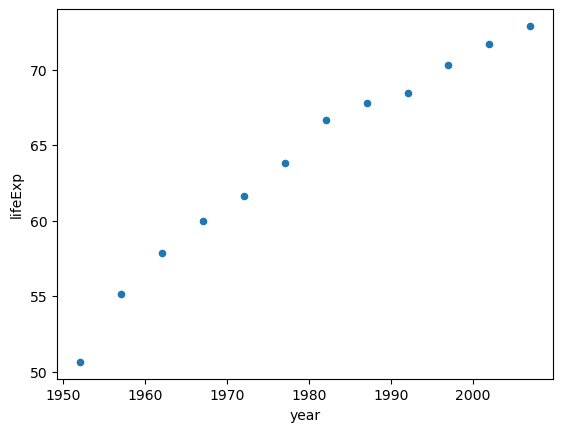

In [5]:
gapminder[gapminder["country"] == "Colombia"].plot(x = 'year', y = 'lifeExp', kind = 'scatter')

Este código creará un gráfico de dispersión con los valores de 'x' en el eje horizontal y los valores de 'y' en el eje vertical.

Puedes personalizar tu gráfico utilizando los métodos de `Matplotlib`. Por ejemplo, para cambiar el color de los puntos, puedes utilizar el parámetro `color`:

<Axes: xlabel='year', ylabel='lifeExp'>

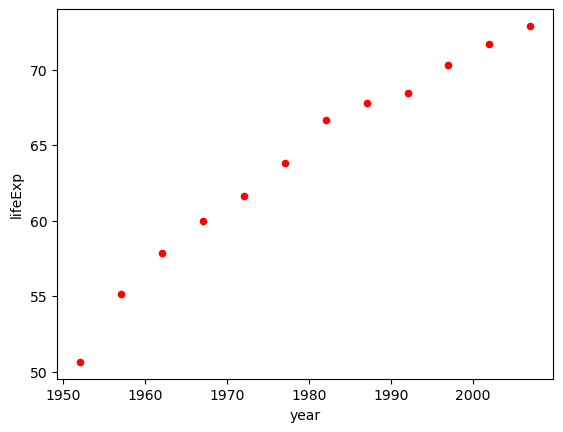

In [6]:
gapminder[gapminder["country"] == "Colombia"].plot(x = 'year', y = 'lifeExp', kind = 'scatter', color = "red")

La función `plot()` de Pandas es utilizada para visualizar datos de un DataFrame o Series. La sintaxis básica es la siguiente:

```python
DataFrame.plot(x = None, y = None, kind = 'line', ax = None, subplots = False, layout = None, figsize = None, use_index = True, title = None, grid = None, legend = True, style = None, logx = False, logy = False, loglog = False, xticks = None, yticks = None, xlim = None, ylim = None, rot = None, xerr = None, yerr = None, label = None, secondary_y = False, **kwds)
```
A continuación, te explico los principales parámetros de esta función:

- `x` y `y`: son las etiquetas o nombres de las columnas que se utilizarán para el eje x y el eje y, respectivamente.
- `kind`: es el tipo de gráfico que se quiere generar, como 'line' para un gráfico de líneas, 'bar' para un gráfico de barras, 'scatter' para un gráfico de dispersión, etc. Por defecto, el valor es 'line'.
- `figsize`: es un parámetro opcional que permite especificar el tamaño del gráfico en pulgadas. El valor por defecto es (6,4).
- `title`: es un parámetro opcional que permite agregar un título al gráfico.
- `xlabel` y `ylabel`: son parámetros opcionales que permiten agregar etiquetas a los ejes x e y del gráfico.
- `xlim` y `ylim`: son parámetros opcionales que permiten establecer los límites del eje x e y, respectivamente.
- `legend`: es un parámetro opcional que permite controlar si se muestra o no la leyenda en el gráfico. El valor por defecto es True.
- `style`: es un parámetro opcional que permite especificar el estilo de la línea o puntos en el gráfico.
- `logx`, `logy` y `loglog`: son parámetros opcionales que permiten mostrar los ejes en una escala logarítmica en lugar de lineal.
- `subplots`: es un parámetro opcional que permite generar un gráfico para cada columna de un DataFrame y presentarlos en un arreglo de subplots.

Hay muchos otros parámetros opcionales que se pueden utilizar con la función `plot()`. Te recomiendo revisar la [documentación oficial de Pandas para obtener más detalles sobre la función y sus parámetros](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.html).

<Axes: xlabel='year'>

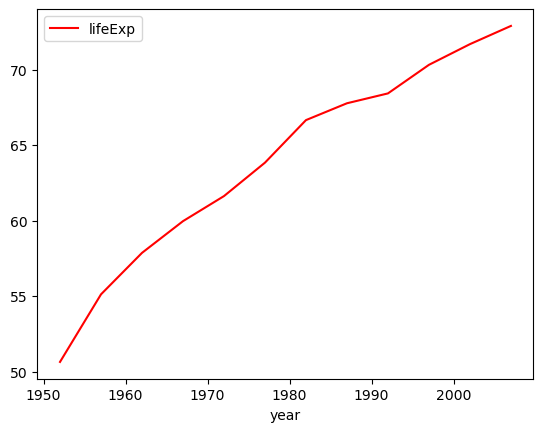

In [7]:
gapminder[gapminder["country"] == "Colombia"].plot(x = 'year', y = 'lifeExp', kind = 'line', color = "red")

In [4]:
import os

# ¿Qué significan los dos puntos?
os.chdir("../Datos")

accidentes1 = pd.read_excel('info_accidentes.xlsx', sheet_name = 'parteA') 
accidentes2 = pd.read_excel('info_accidentes.xlsx', sheet_name = 'parteB') 

# Hace un inner join
accidentes = pd.merge(accidentes1, accidentes2, on = ['Direccion', 'Fecha'])
accidentes["Fecha"] = pd.to_datetime(accidentes["Fecha"])
accidentes["HoraOcurrencia"] = pd.to_datetime(accidentes["HoraOcurrencia"])

/var/folders/yz/w0xwt9gn5zq7ss8mg0n8hr9h0000gp/T/ipykernel_4676/1267460104.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  accidentes["Fecha"] = pd.to_datetime(accidentes["Fecha"])
/var/folders/yz/w0xwt9gn5zq7ss8mg0n8hr9h0000gp/T/ipykernel_4676/1267460104.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  accidentes["HoraOcurrencia"] = pd.to_datetime(accidentes["HoraOcurrencia"])


In [5]:
n_accidentes = accidentes.groupby("Fecha").size().reset_index(name = "Número de accidentes")
n_accidentes

,Fecha,Número de accidentes
0,2016-01-01,28
1,2016-01-02,104
2,2016-01-03,90
3,2016-01-04,122
4,2016-01-05,48
...,...,...
361,2016-12-27,112
362,2016-12-28,94
363,2016-12-29,95
364,2016-12-30,86


<Axes: xlabel='Fecha'>

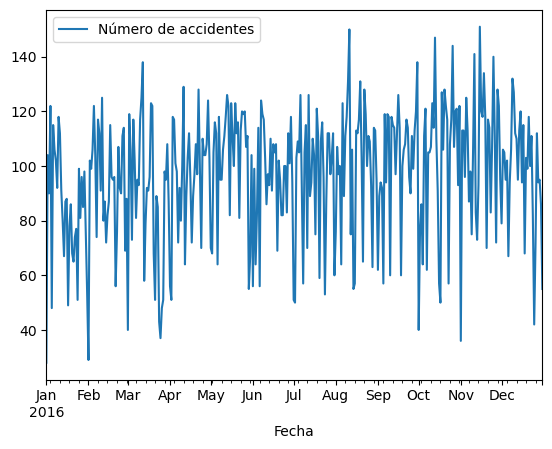

In [6]:
accidentes.groupby("Fecha").size().reset_index(name = "Número de accidentes") \
    .plot(x = "Fecha", y = "Número de accidentes", kind = "line")

In [7]:
import matplotlib.pyplot as plt

# plt.plot(n_accidentes["Fecha"], n_accidentes["Número de accidentes"], color = "blue")
# plt.scatter(n_accidentes["Fecha"], n_accidentes["Número de accidentes"], color = "blue")
# plt.hist(n_accidentes["Número de accidentes"])

<Axes: xlabel='Fecha'>

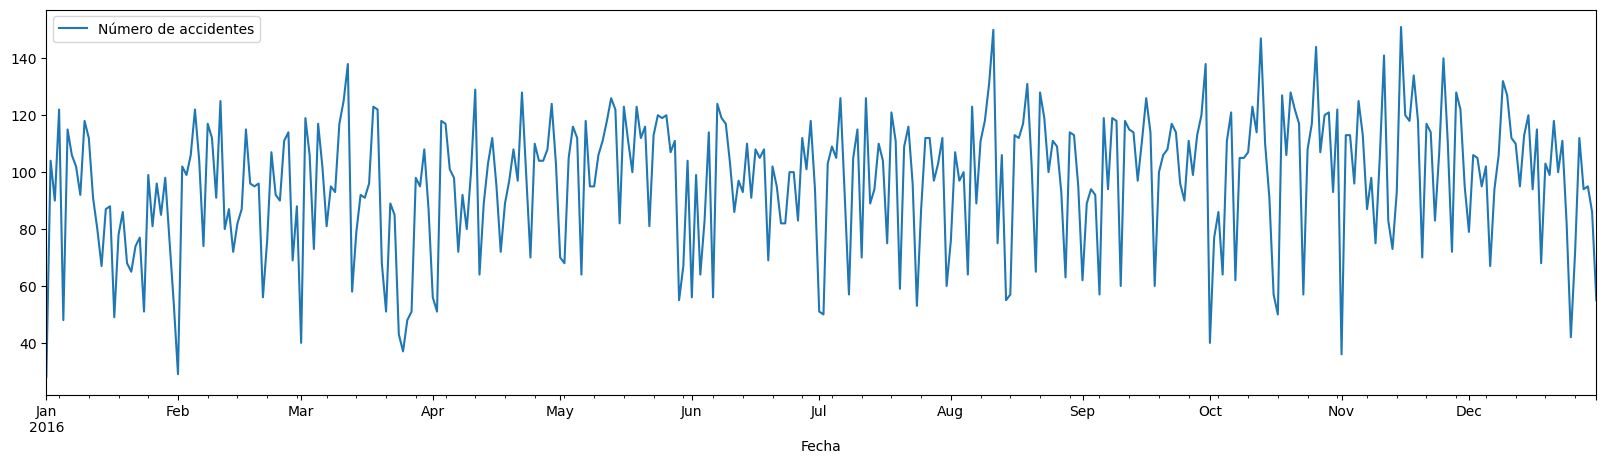

In [8]:
# Cambiemosle el tamaño al gráfico
accidentes.groupby("Fecha").size().reset_index(name = "Número de accidentes") \
    .plot(x = "Fecha", y = "Número de accidentes", kind = "line", figsize = (20, 5))

<Axes: title={'center': 'Accidentes diarios en Bogotá (2016)'}, xlabel='Fecha'>

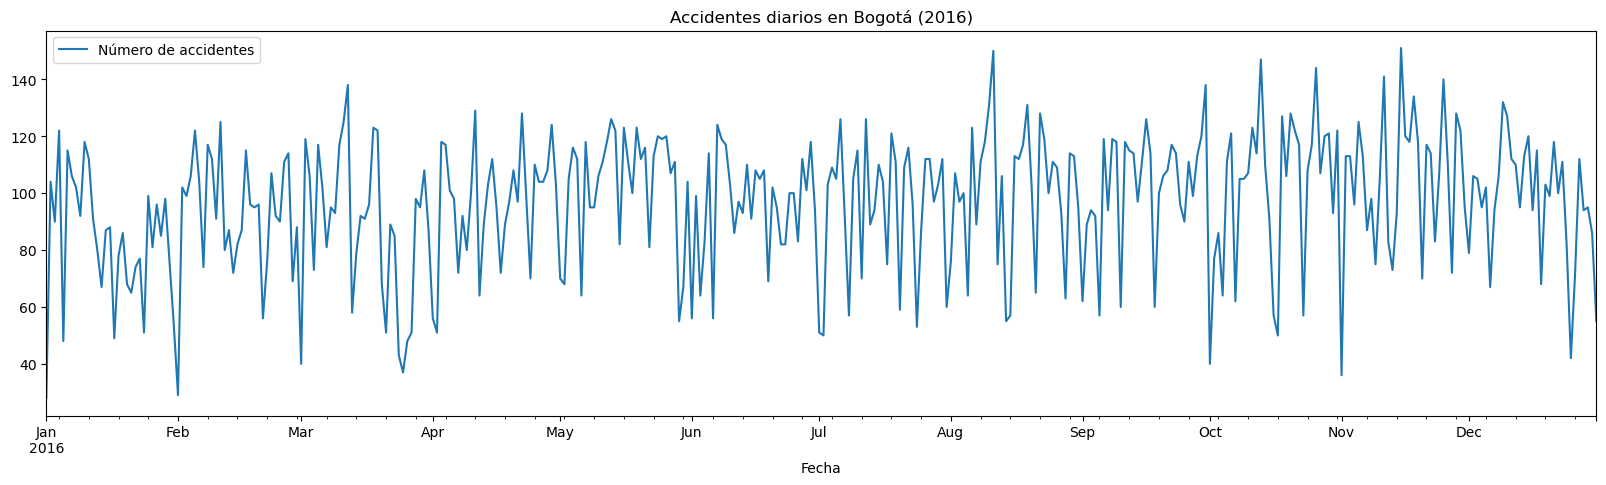

In [9]:
# Pongamosle título
accidentes.groupby("Fecha").size().reset_index(name = "Número de accidentes") \
    .plot(x = "Fecha", y = "Número de accidentes", kind = "line", figsize = (20, 5), 
          title = "Accidentes diarios en Bogotá (2016)")

<Axes: title={'center': 'Accidentes diarios en Bogotá (2016)'}, xlabel='Fecha'>

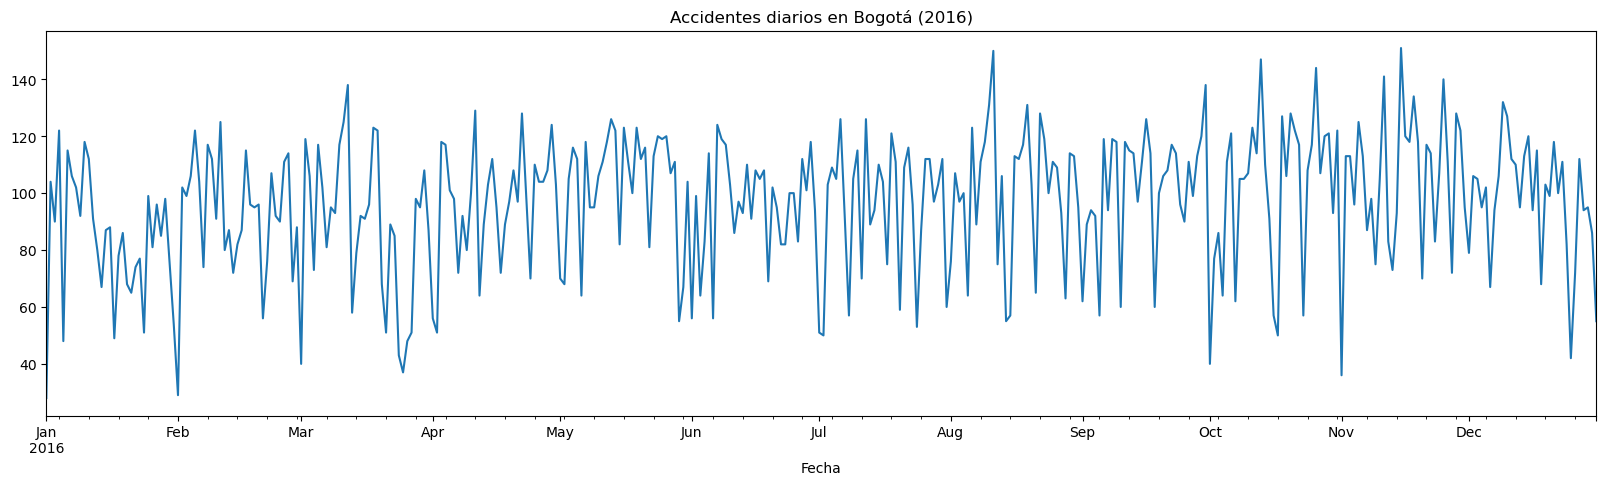

In [10]:
# Quitemosle la legenda
accidentes.groupby("Fecha").size().reset_index(name = "Número de accidentes") \
    .plot(x = "Fecha", y = "Número de accidentes", kind = "line", figsize = (20, 5), 
          title = "Accidentes diarios en Bogotá (2016)", legend = False)

<Axes: title={'center': 'Accidentes diarios en Bogotá (2016)'}, xlabel='Fecha'>

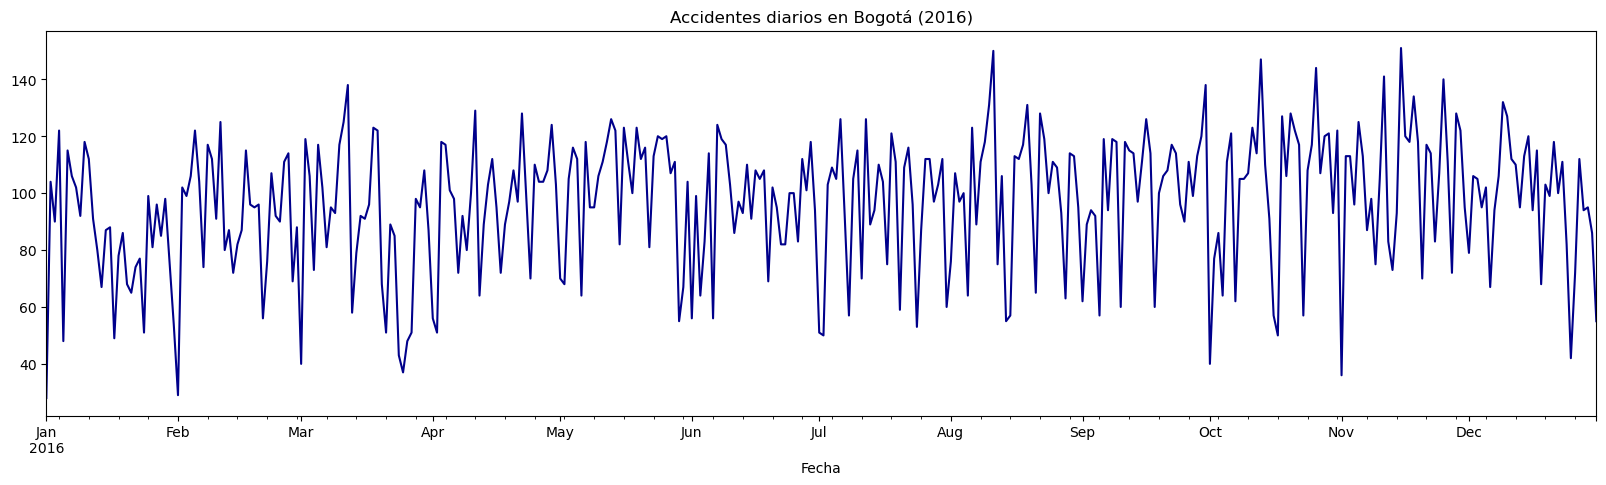

In [11]:
# Pongamosle color a la línea
accidentes.groupby("Fecha").size().reset_index(name = "Número de accidentes") \
    .plot(x = "Fecha", y = "Número de accidentes", kind = "line", figsize = (20, 5), 
          title = "Accidentes diarios en Bogotá (2016)", legend = False,
          color = "darkblue")

¿Cómo hago para saber qué colores existen? Por defecto, `pandas` y `matplotlib` tienen algunas palabras asociadas a algunos [colores](https://matplotlib.org/stable/gallery/color/named_colors.html)

<center>
<div>
<img src="img/colors.png" width="400"/>
</div>
</center>

<Axes: title={'center': 'Accidentes diarios en Bogotá (2016)'}, xlabel='Fecha'>

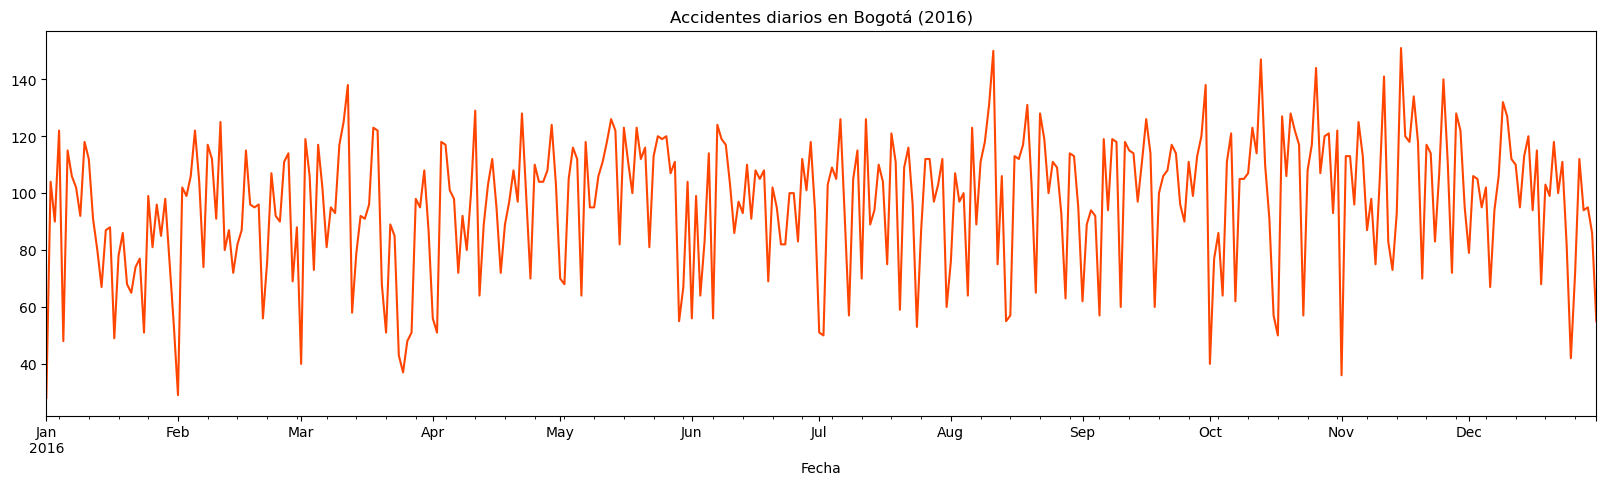

In [12]:
# Pongamosle color a la línea
accidentes.groupby("Fecha").size().reset_index(name = "Número de accidentes") \
    .plot(x = "Fecha", y = "Número de accidentes", kind = "line", figsize = (20, 5), 
          title = "Accidentes diarios en Bogotá (2016)", legend = False,
          color = "orangered")

<Axes: title={'center': 'Accidentes diarios en Bogotá (2016)'}, xlabel='Fecha'>

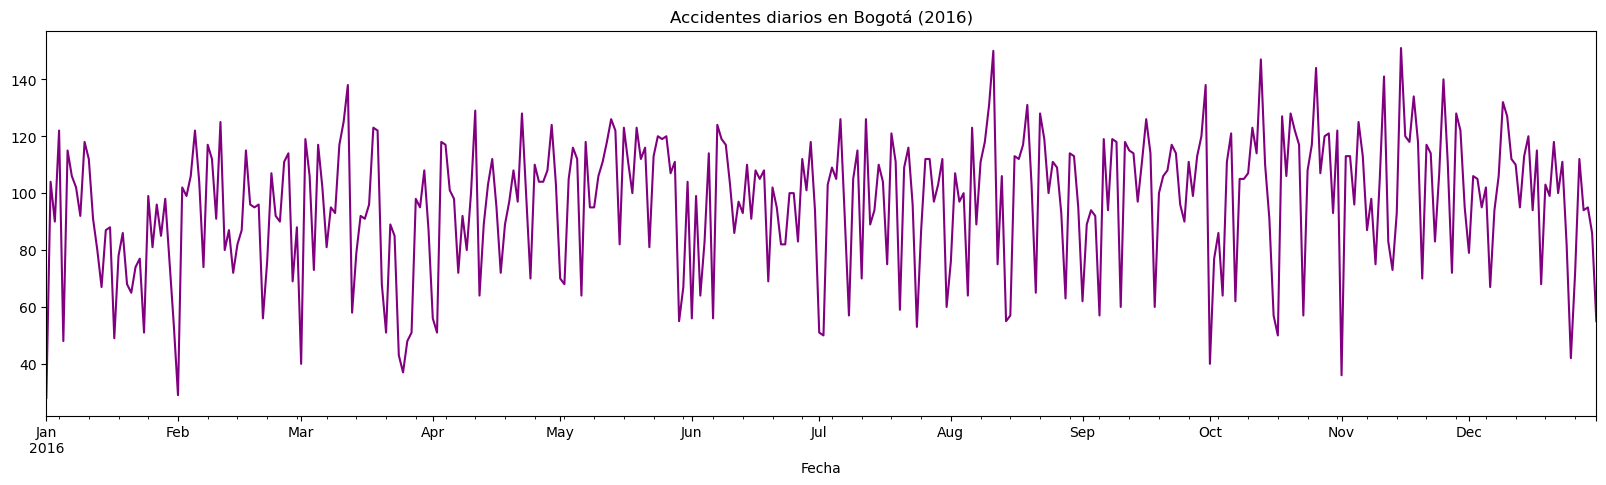

In [13]:
# Pongamosle color a la línea
accidentes.groupby("Fecha").size().reset_index(name = "Número de accidentes") \
    .plot(x = "Fecha", y = "Número de accidentes", kind = "line", figsize = (20, 5), 
          title = "Accidentes diarios en Bogotá (2016)", legend = False,
          color = "purple")

<Axes: title={'center': 'Accidentes diarios en Bogotá (2016)'}, xlabel='Fecha'>

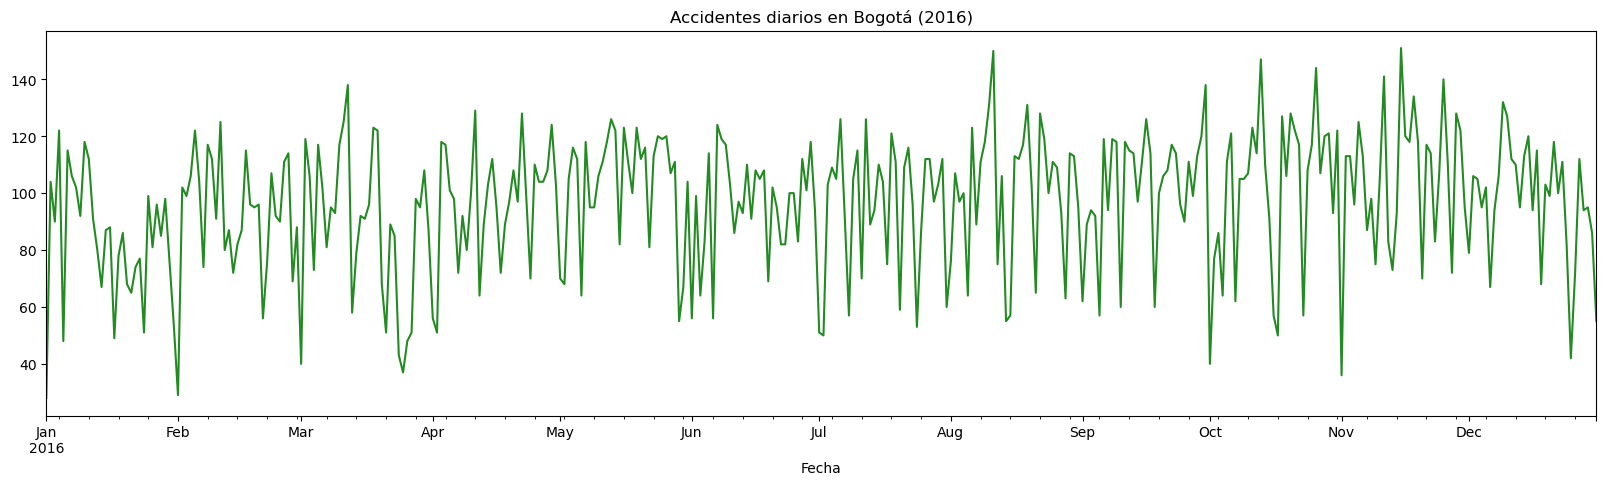

In [14]:
# Pongamosle color a la línea
accidentes.groupby("Fecha").size().reset_index(name = "Número de accidentes") \
    .plot(x = "Fecha", y = "Número de accidentes", kind = "line", figsize = (20, 5), 
          title = "Accidentes diarios en Bogotá (2016)", legend = False,
          color = "forestgreen")

Sin embargo, puede crear cualquier color que quiera a partir del [código HEX](https://www.google.com/search?q=HEX+color&rlz=1C1CHZN_enCO1034CO1034&sxsrf=APwXEdfScUmp_Pr0bIhq9xV33av52uCWKA%3A1680729192725&ei=aOQtZOv1K--FwbkP1PCygAM&ved=0ahUKEwjryfuT1JP-AhXvQjABHVS4DDAQ4dUDCA8&uact=5&oq=HEX+color&gs_lcp=Cgxnd3Mtd2l6LXNlcnAQAzIHCAAQigUQQzIHCAAQigUQQzIHCAAQigUQQzIHCAAQigUQQzIGCAAQBxAeMgcIABCKBRBDMggIABCABBDLATIICAAQgAQQywEyBggAEAcQHjIGCAAQBxAeOgoIABBHENYEELADOgoIABCKBRCwAxBDSgQIQRgAUNYPWL0RYPYUaAJwAXgAgAHFAYgBlQSSAQMwLjOYAQCgAQHIAQrAAQE&sclient=gws-wiz-serp)


<center>
<div>
<img src="img/HEX.png" width="400"/>
</div>
</center>

<Axes: title={'center': 'Accidentes diarios en Bogotá (2016)'}, xlabel='Fecha'>

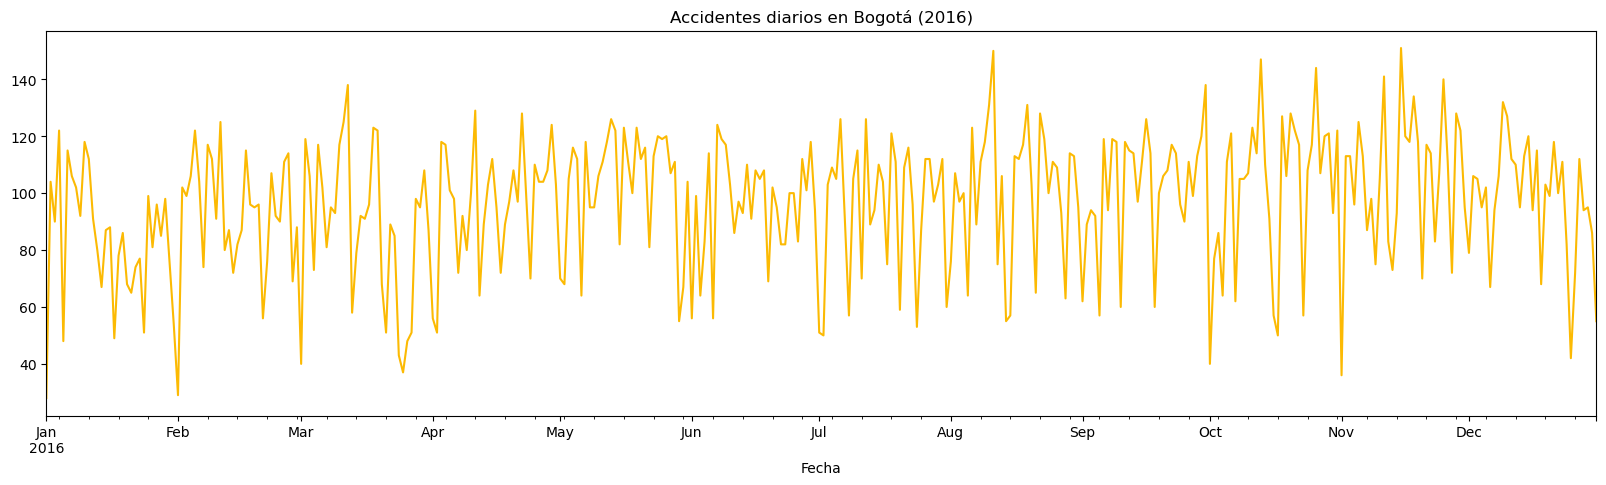

In [15]:
# Pongamosle color a la línea
accidentes.groupby("Fecha").size().reset_index(name = "Número de accidentes") \
    .plot(x = "Fecha", y = "Número de accidentes", kind = "line", figsize = (20, 5),
          title = "Accidentes diarios en Bogotá (2016)", legend = False,
          color = "#fcba03")

Exploremos otro tipo de gráficos como los histogramas. Veamos cómo se distribuyen la cantidad de accidentes por horas del día

<Axes: ylabel='Frequency'>

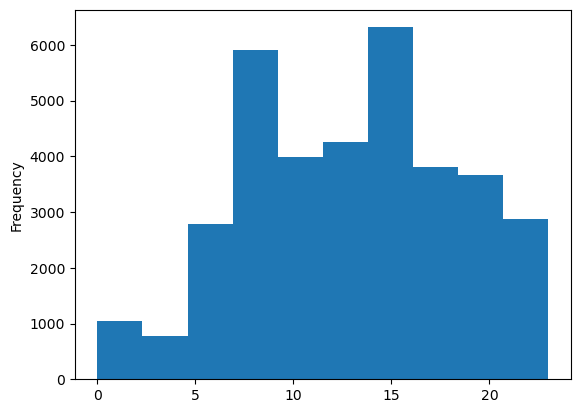

In [16]:
# Hay dos picos de accidentalidad: Al rededor de las 7-8 am y 2-3 pm
accidentes["HoraOcurrencia"].dt.hour.plot(kind = "hist")

<Axes: title={'center': 'Distribución de los accidentes por hora del día'}, ylabel='Frequency'>

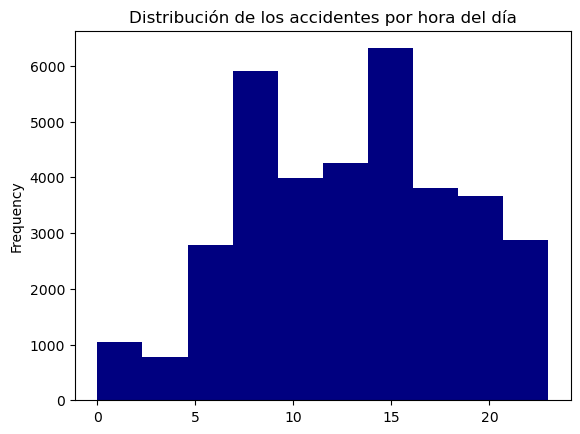

In [17]:
accidentes["HoraOcurrencia"].dt.hour.plot(kind = "hist", color = "navy", 
                                          title = "Distribución de los accidentes por hora del día")

<Axes: title={'center': 'Relación entre heridos y muertos'}, xlabel='Número de muertos', ylabel='Número de heridos'>

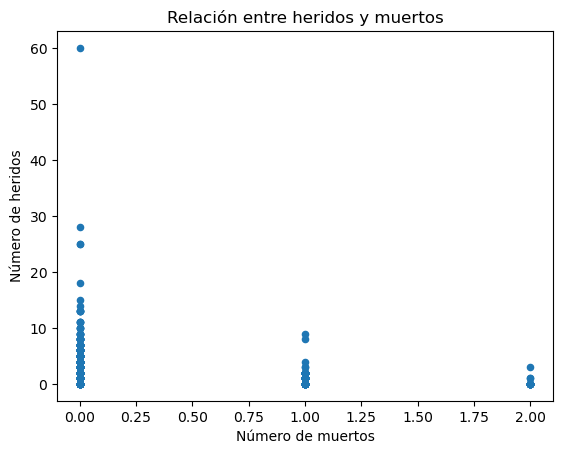

In [18]:
accidentes.plot(x = "TotalMuertos", y = "TotalHeridos", kind = "scatter", 
                xlabel = "Número de muertos", ylabel = "Número de heridos",
                title = "Relación entre heridos y muertos")

In [19]:
# Creemos un gráfico de barras en donde se visualice la cantidad de accidentes por tipo
tipos_accidentes = accidentes["GravedadNombre"].value_counts().reset_index()
tipos_accidentes

,GravedadNombre,count
0,Solo Daños,24209
1,Con Heridos,10654
2,Con Muertos,560


<Axes: title={'center': 'Cantidad de accidentes por tipo'}, xlabel='Tipo de accidente', ylabel='Cantidad'>

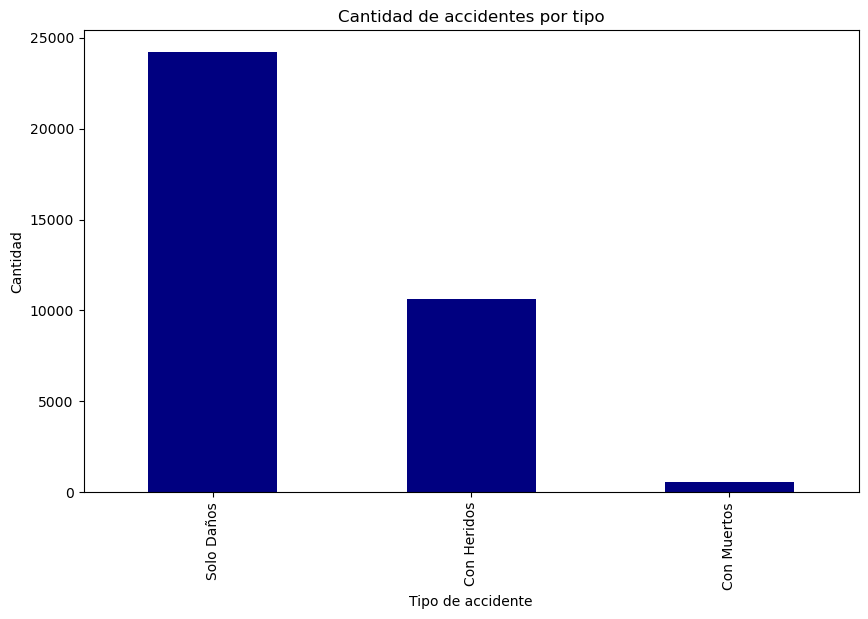

In [20]:
tipos_accidentes.plot(x = "GravedadNombre", y = "count", kind = "bar", 
                      xlabel = "Tipo de accidente", ylabel = "Cantidad", 
                      color = "navy", legend = False, 
                      title = "Cantidad de accidentes por tipo",
                      figsize = (10, 6))

In [21]:
# ¿Cómo pasamos estos números a porcentajes?
tipos_accidentes["Proporción"] = tipos_accidentes["count"]/tipos_accidentes["count"].sum()

<Axes: ylabel='Proporción'>

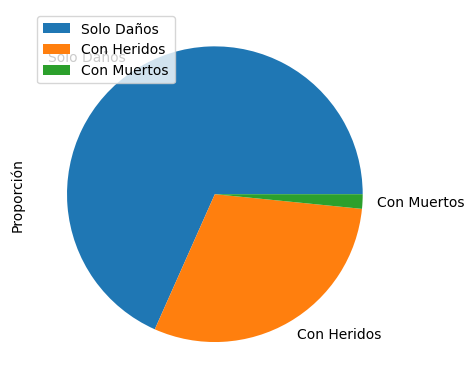

In [22]:
# Si vamos a hacer un gráfico de torta el índice debe reflejar las categoría a visualizar
tipos_accidentes.set_index("GravedadNombre").plot(y = "Proporción", kind = "pie")

Esos colores están HORRIBLES. Busquemos alguna paleta en mi página favorita: [coolors](https://coolors.co/)

<center>
<div>
<img src="img/coolors.png" width="800"/>
</div>
</center>

<Axes: ylabel='Proporción'>

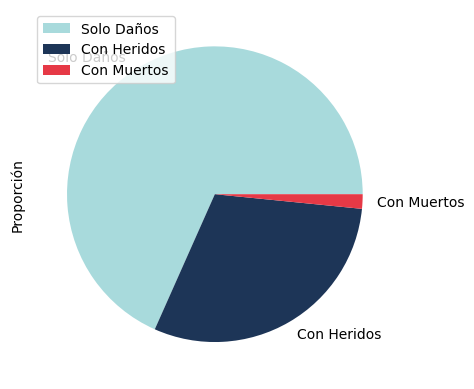

In [23]:
tipos_accidentes.set_index("GravedadNombre").plot(y = "Proporción", kind = "pie", 
                                         colors = ["#a8dadc", "#1d3557", "#e63946"])

También podemos importar [paletas usando el paquete seaborn](https://seaborn.pydata.org/tutorial/color_palettes.html)

<center>
<div>
<img src="img/palette.png" width="800"/>
</div>
</center>

In [24]:
import seaborn as sns
sns.color_palette("Spectral")

[(0.8853517877739331, 0.3190311418685121, 0.29042675893886966),
 (0.9873125720876587, 0.6473663975394078, 0.3642445213379469),
 (0.9971549404075356, 0.9118031526336025, 0.6010765090349866),
 (0.9288735101883892, 0.9715494040753557, 0.6380622837370243),
 (0.6334486735870821, 0.8521337946943485, 0.6436755094194541),
 (0.2800461361014994, 0.6269896193771626, 0.7024221453287197)]

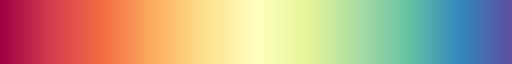

In [25]:
sns.color_palette("Spectral", as_cmap = True)

In [26]:
sns.color_palette("Paired")

[(0.6509803921568628, 0.807843137254902, 0.8901960784313725),
 (0.12156862745098039, 0.47058823529411764, 0.7058823529411765),
 (0.6980392156862745, 0.8745098039215686, 0.5411764705882353),
 (0.2, 0.6274509803921569, 0.17254901960784313),
 (0.984313725490196, 0.6039215686274509, 0.6),
 (0.8901960784313725, 0.10196078431372549, 0.10980392156862745),
 (0.9921568627450981, 0.7490196078431373, 0.43529411764705883),
 (1.0, 0.4980392156862745, 0.0),
 (0.792156862745098, 0.6980392156862745, 0.8392156862745098),
 (0.41568627450980394, 0.23921568627450981, 0.6039215686274509),
 (1.0, 1.0, 0.6),
 (0.6941176470588235, 0.34901960784313724, 0.1568627450980392)]

In [27]:
sns.color_palette("Blues")

[(0.8584083044982699, 0.9134486735870818, 0.9645674740484429),
 (0.7309496347558632, 0.8394771241830065, 0.9213225682429834),
 (0.5356862745098039, 0.746082276047674, 0.8642522106881968),
 (0.32628988850442137, 0.6186236063052672, 0.802798923490965),
 (0.16696655132641292, 0.48069204152249134, 0.7291503267973857),
 (0.044059976931949255, 0.3338869665513264, 0.6244521337946944)]

In [28]:
sns.color_palette("viridis")

[(0.275191, 0.194905, 0.496005),
 (0.212395, 0.359683, 0.55171),
 (0.153364, 0.497, 0.557724),
 (0.122312, 0.633153, 0.530398),
 (0.288921, 0.758394, 0.428426),
 (0.626579, 0.854645, 0.223353)]

In [29]:
sns.color_palette('RdYlGn')

[(0.8899653979238754, 0.2867358708189158, 0.19815455594002307),
 (0.9873125720876587, 0.6473663975394078, 0.3642445213379469),
 (0.9971549404075356, 0.9118031526336025, 0.6010765090349866),
 (0.8918877354863515, 0.954479046520569, 0.6010765090349867),
 (0.6165321030372937, 0.8359092656670513, 0.41191849288735105),
 (0.22468281430219145, 0.6558246828143022, 0.3444059976931949)]

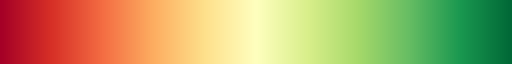

In [30]:
sns.color_palette('RdYlGn', as_cmap = True)

In [31]:
sns.color_palette('RdYlGn_r')

[(0.2246828143021916, 0.6558246828143023, 0.34440599769319497),
 (0.6165321030372936, 0.8359092656670511, 0.41191849288735105),
 (0.8918877354863515, 0.954479046520569, 0.6010765090349867),
 (0.9971549404075356, 0.9118031526336025, 0.6010765090349866),
 (0.9873125720876587, 0.647366397539408, 0.36424452133794694),
 (0.8899653979238754, 0.28673587081891583, 0.19815455594002307)]

<Axes: ylabel='Proporción'>

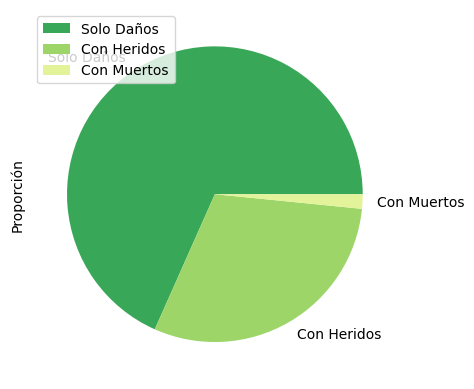

In [32]:
tipos_accidentes.set_index("GravedadNombre").plot(y = "Proporción", kind = "pie", 
                                         colors = sns.color_palette('RdYlGn_r'))

<Axes: ylabel='Proporción'>

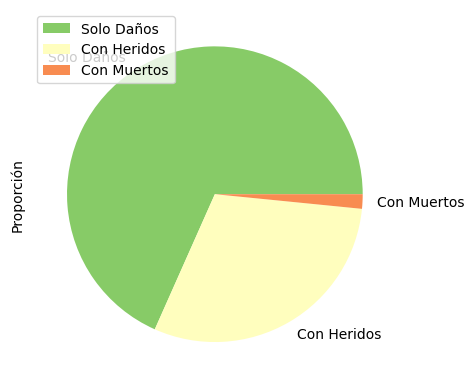

In [33]:
tipos_accidentes.set_index("GravedadNombre").plot(y = "Proporción", kind = "pie", 
                                         colors = sns.color_palette('RdYlGn_r', n_colors = 3))

<Axes: title={'center': 'Gravedad de los accidentes'}>

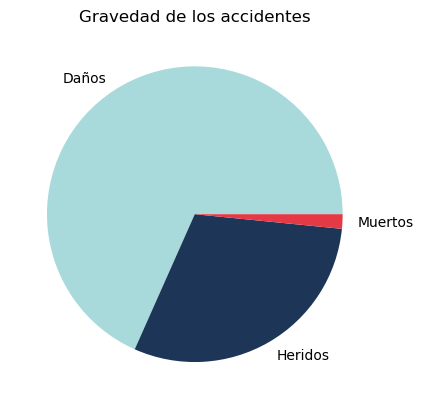

In [34]:
# También se pueden poner los labels de forma manual en vez de usar el índice
tipos_accidentes.plot(y = "Proporción", 
                      labels = ["Daños", "Heridos", "Muertos"], 
                      kind = "pie", 
                      colors = ["#a8dadc", "#1d3557", "#e63946"],
                      ylabel = "",
                      title = "Gravedad de los accidentes",
                      legend = False)

<Axes: title={'center': 'Gravedad de los accidentes'}>

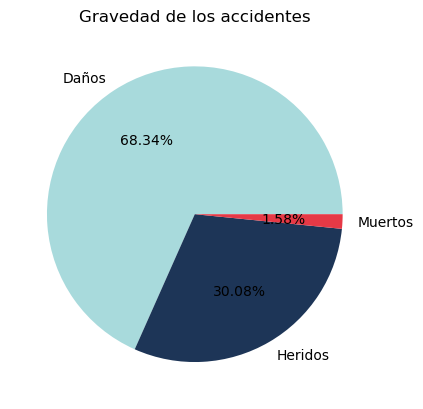

In [35]:
# Podemos añadirle los porcentajes
tipos_accidentes.plot(y = "Proporción", 
                      labels = ["Daños", "Heridos", "Muertos"], 
                      kind = "pie", 
                      colors = ["#a8dadc", "#1d3557", "#e63946"],
                      ylabel = "",
                      title = "Gravedad de los accidentes",
                      legend = False,
                      autopct = '%1.2f%%',)

<Axes: title={'center': 'Gravedad de los accidentes'}>

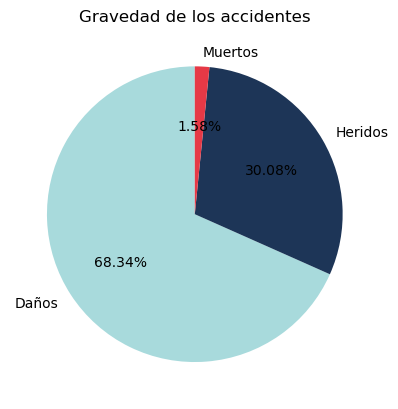

In [36]:
# Podemos mover el pie
tipos_accidentes.plot(y = "Proporción", 
                      labels = ["Daños", "Heridos", "Muertos"], 
                      kind = "pie", 
                      colors = ["#a8dadc", "#1d3557", "#e63946"],
                      ylabel = "",
                      title = "Gravedad de los accidentes",
                      legend = False,
                      autopct = '%1.2f%%',
                      startangle = 90)

<Axes: title={'center': 'Gravedad de los accidentes'}>

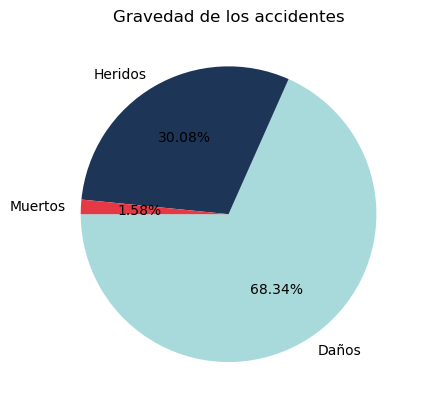

In [37]:
# Podemos mover el pie
tipos_accidentes.plot(y = "Proporción", 
                      labels = ["Daños", "Heridos", "Muertos"], 
                      kind = "pie", 
                      colors = ["#a8dadc", "#1d3557", "#e63946"],
                      ylabel = "",
                      title = "Gravedad de los accidentes",
                      legend = False,
                      autopct = '%1.2f%%',
                      startangle = 180)

<Axes: title={'center': 'Gravedad de los accidentes'}>

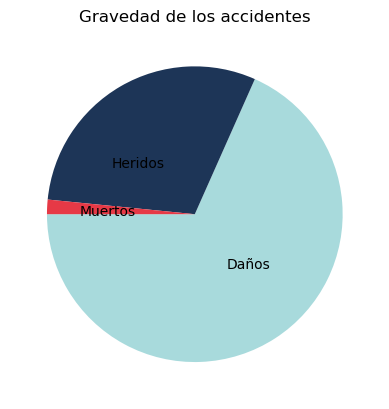

In [38]:
# Podemos mover la legenda
tipos_accidentes.plot(y = "Proporción", 
                      labels = ["Daños", "Heridos", "Muertos"], 
                      kind = "pie", 
                      colors = ["#a8dadc", "#1d3557", "#e63946"],
                      ylabel = "",
                      title = "Gravedad de los accidentes",
                      legend = False,
                      startangle = 180,
                      # Distancia de los labels al centro
                      labeldistance = 0.4)

<Axes: title={'center': 'Gravedad de los accidentes'}>

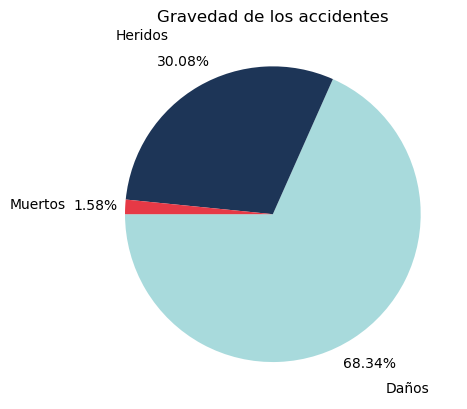

In [39]:
# Podemos mover los porcentajes
tipos_accidentes.plot(y = "Proporción", 
                      labels = ["Daños", "Heridos", "Muertos"], 
                      kind = "pie", 
                      colors = ["#a8dadc", "#1d3557", "#e63946"],
                      ylabel = "",
                      title = "Gravedad de los accidentes",
                      legend = False,
                      startangle = 180,
                      # Distancia de los labels al centro
                      labeldistance = 1.4,
                      # Distancia de los porcentajes al centro
                      autopct = '%1.2f%%',
                      pctdistance = 1.2
                      )

<Axes: title={'center': 'Gravedad de los accidentes'}>

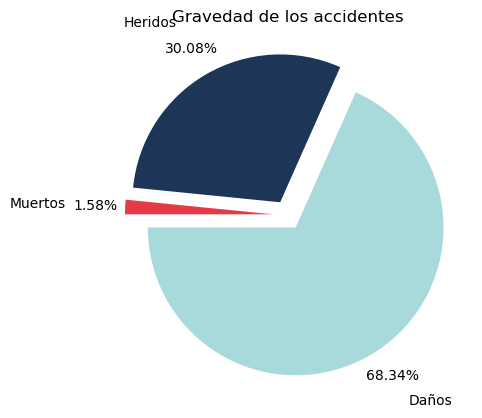

In [40]:
# Separar las porciones
tipos_accidentes.plot(y = "Proporción", 
                      labels = ["Daños", "Heridos", "Muertos"], 
                      kind = "pie", 
                      colors = ["#a8dadc", "#1d3557", "#e63946"],
                      ylabel = "",
                      title = "Gravedad de los accidentes",
                      legend = False,
                      startangle = 180,
                      # Distancia de los labels al centro
                      labeldistance = 1.4,
                      # Distancia de los porcentajes al centro
                      autopct = '%1.2f%%',
                      pctdistance = 1.2,
                      # Mover porciones
                      explode = [0.1, 0.1, 0.1]
                      )

<Axes: title={'center': 'Gravedad de los accidentes \n\n'}>

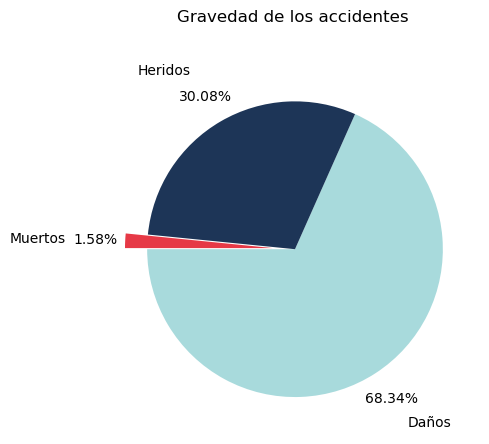

In [41]:
# Resaltar una porción
tipos_accidentes.plot(y = "Proporción", 
                      labels = ["Daños", "Heridos", "Muertos"], 
                      kind = "pie", 
                      colors = ["#a8dadc", "#1d3557", "#e63946"],
                      ylabel = "",
                      title = "Gravedad de los accidentes \n\n",
                      legend = False,
                      startangle = 180,
                      # Distancia de los labels al centro
                      labeldistance = 1.4,
                      # Distancia de los porcentajes al centro
                      autopct = '%1.2f%%',
                      pctdistance = 1.2,
                      # Mover porciones
                      explode = [0, 0, 0.15]
                      )

## Gráficos no tan rápidos

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

In [43]:
os.listdir("../Datos")

['RESPPANWW.xlsx',
 'exp_col23.xlsx',
 'olist_sellers_dataset.csv',
 'info_accidentes.xlsx',
 'CSUSHPINSA.xlsx',
 'product_category_name_translation.csv',
 'trade_agg23.xlsx',
 'olist_orders_dataset.csv',
 'olist_order_items_dataset.csv',
 'gapminder.xlsx',
 'trade_i_baci_a_22.csv',
 'olist_customers_dataset.csv',
 'olist_geolocation_dataset.csv',
 'olist_order_payments_dataset.csv',
 'olist_order_reviews_dataset.csv',
 'olist_products_dataset.csv']

In [44]:
gapminder = pd.read_excel('../Datos/gapminder.xlsx')

In [45]:
gapminder.head()

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
0,Afghanistan,Asia,1952,28.801,8425333,779.445314,AFG,4
1,Afghanistan,Asia,1957,30.332,9240934,820.853030,AFG,4
2,Afghanistan,Asia,1962,31.997,10267083,853.100710,AFG,4
3,Afghanistan,Asia,1967,34.020,11537966,836.197138,AFG,4
4,Afghanistan,Asia,1972,36.088,13079460,739.981106,AFG,4


In [46]:
gapminder["country"].unique()

array(['Afghanistan', 'Albania', 'Algeria', 'Angola', 'Argentina',
       'Australia', 'Austria', 'Bahrain', 'Bangladesh', 'Belgium',
       'Benin', 'Bolivia', 'Bosnia and Herzegovina', 'Botswana', 'Brazil',
       'Bulgaria', 'Burkina Faso', 'Burundi', 'Cambodia', 'Cameroon',
       'Canada', 'Central African Republic', 'Chad', 'Chile', 'China',
       'Colombia', 'Comoros', 'Congo, Dem. Rep.', 'Congo, Rep.',
       'Costa Rica', "Cote d'Ivoire", 'Croatia', 'Cuba', 'Czech Republic',
       'Denmark', 'Djibouti', 'Dominican Republic', 'Ecuador', 'Egypt',
       'El Salvador', 'Equatorial Guinea', 'Eritrea', 'Ethiopia',
       'Finland', 'France', 'Gabon', 'Gambia', 'Germany', 'Ghana',
       'Greece', 'Guatemala', 'Guinea', 'Guinea-Bissau', 'Haiti',
       'Honduras', 'Hong Kong, China', 'Hungary', 'Iceland', 'India',
       'Indonesia', 'Iran', 'Iraq', 'Ireland', 'Israel', 'Italy',
       'Jamaica', 'Japan', 'Jordan', 'Kenya', 'Korea, Dem. Rep.',
       'Korea, Rep.', 'Kuwait', 'Leba

In [47]:
gapminder["year"].unique()

array([1952, 1957, 1962, 1967, 1972, 1977, 1982, 1987, 1992, 1997, 2002,
       2007])

In [48]:
# Seleccionar un país
peru = gapminder.loc[gapminder["country"] == 'Peru', :].reset_index(drop = True)
peru 

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
0,Peru,Americas,1952,43.902,8025700,3758.523437,PER,604
1,Peru,Americas,1957,46.263,9146100,4245.256698,PER,604
2,Peru,Americas,1962,49.096,10516500,4957.037982,PER,604
3,Peru,Americas,1967,51.445,12132200,5788.093330,PER,604
4,Peru,Americas,1972,55.448,13954700,5937.827283,PER,604
5,Peru,Americas,1977,58.447,15990099,6281.290855,PER,604
6,Peru,Americas,1982,61.406,18125129,6434.501797,PER,604
7,Peru,Americas,1987,64.134,20195924,6360.943444,PER,604
8,Peru,Americas,1992,66.458,22430449,4446.380924,PER,604
9,Peru,Americas,1997,68.386,24748122,5838.347657,PER,604


<Axes: xlabel='year'>

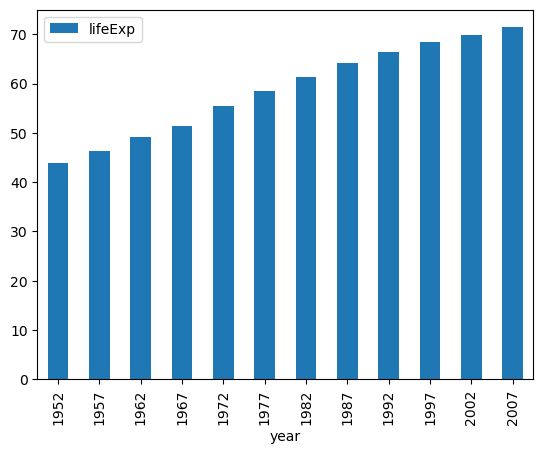

In [49]:
# Graficas rápidas
# .plot()
peru.plot(kind = "bar", x = "year", y = "lifeExp")

Text(0, 0.5, 'Expectativa de vida')

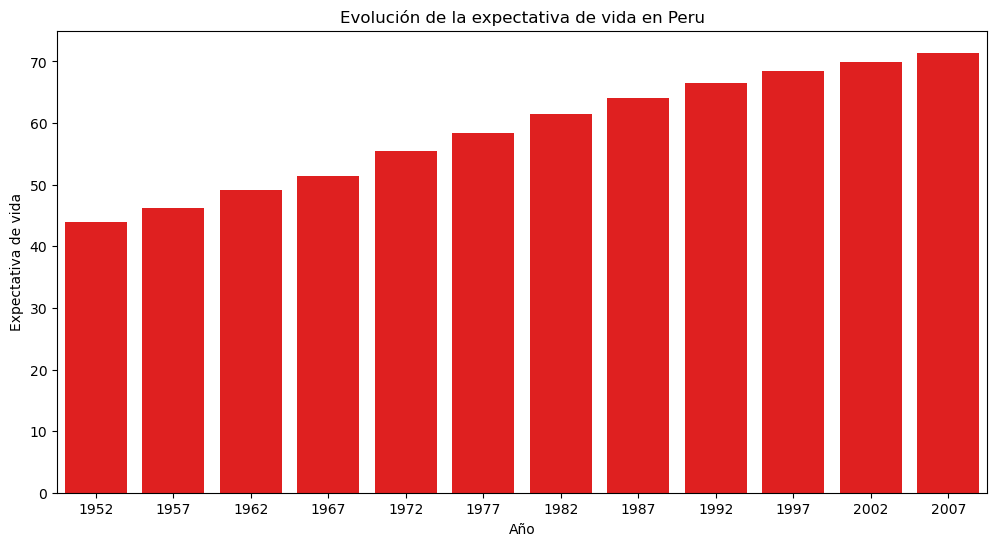

In [50]:
fig, ax = plt.subplots(figsize = (12, 6))
sns.barplot(data = peru, x = "year", y = "lifeExp", color = "red")
plt.title("Evolución de la expectativa de vida en Peru")
plt.xlabel("Año")
plt.ylabel("Expectativa de vida")

In [51]:
continents = gapminder.groupby(["year", "continent"])[["gdpPercap", "lifeExp", "pop"]].median().reset_index()

<Axes: xlabel='lifeExp', ylabel='Count'>

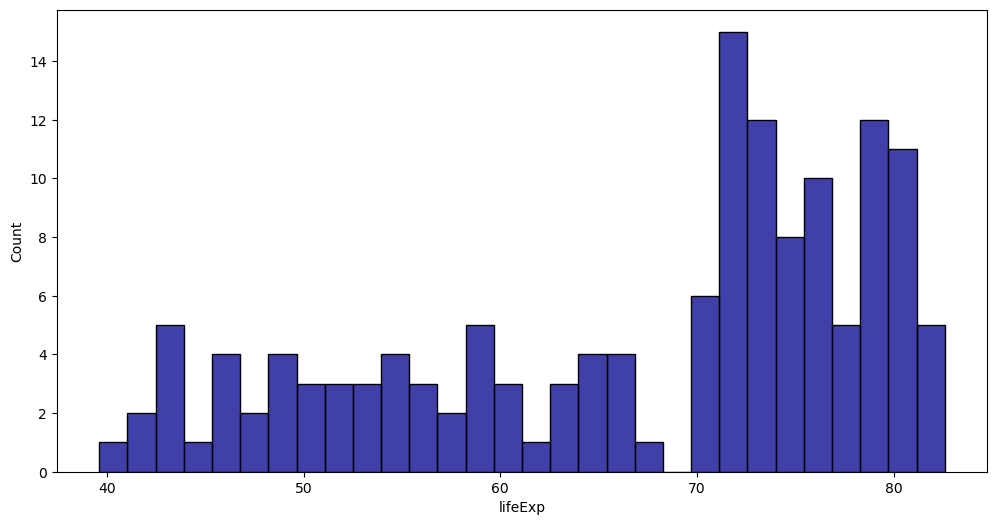

In [53]:
fig, ax = plt.subplots(figsize = (12, 6))
sns.histplot(data = gapminder[gapminder.year == 2007], x = "lifeExp", color = "darkblue", bins = 30)

<Axes: xlabel='gdpPercap', ylabel='lifeExp'>

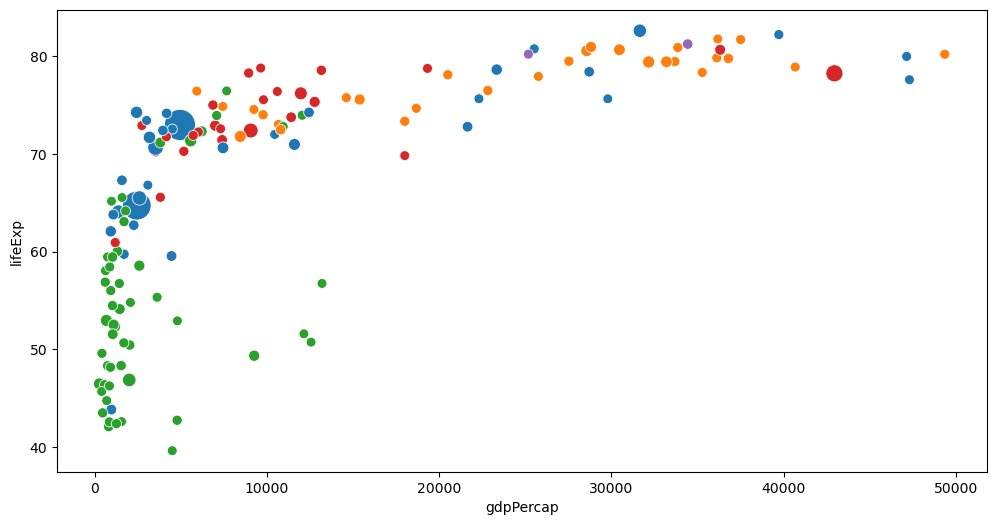

In [55]:
fig, ax = plt.subplots(figsize = (12, 6))
sns.scatterplot(data = gapminder[gapminder.year == 2007], x = "gdpPercap", y = "lifeExp", size = "pop", sizes = (50, 500), hue = "continent", legend=False)

## Ejercicios
Vamos a utilizar un conjunto de bases de datos de la tienda brasileña de comercio electrónico Olist. Los datos tienen información de alrededor de 100 mil pedidos entre 2016 y 2018 y dependiendo de la base podrá ver diferentes dimensiones de cada pedido como el estado, el precio, el pago, el rendimiento del flete, la ubicación del cliente, los atributos del producto, las reseñas escritas por los clientes, etc. Notará además que algunos datos tienen una geolocalización que relaciona los códigos postales brasileños con las coordenadas latitud/longitud.

Los datos que manipulará a continuación son datos comerciales reales, sin embargo se han anonimizado y las referencias a las empresas y socios en el texto de revisión se han reemplazado con los nombres de las grandes casas de Game of Thrones.

El esquema de los datos se presenta en la siguiente figura: 
<center>
<div>
<img src="img/diagrama_bases.png" width="800"/>
</div>
</center>

Para más información puede visitar la siguiente [competencia de Kaggle](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce)

Luego de entender el esquema de datos, el primer paso es importar e inspeccionar someramente las siguientes bases de datos:
1. Importe la base de datos `olist_customers_dataset.csv` para obtener los directorios de clientes.
2. Importe la base de datos `olist_geolocation_dataset.csv` para obtener la información espacial de [Brasil](https://es.wikipedia.org/wiki/Geograf%C3%ADa_de_Brasil#/media/Archivo:Brasil_administrative_map_ES.png).
3. Importe la base de datos `olist_order_payments_dataset.csv` para obtener información sobre los pagos.
4. Importe la base de datos `olist_order_items_dataset.csv` para obtener la información de los productos vendidos.
5. Importe la base de datos `olist_products_dataset.csv` para obtener información de los productos.
6. Importe la base de datos `olist_sellers_dataset.csv` para obtener la información de los vendedores.
7. Importe la base de datos `olist_orders_dataset.csv` para obtener información de las entregas.
8. Importe la base de datos `product_category_name_translation.csv` para traducir a inglés los tipos de productos

In [56]:
clientes = pd.read_csv('olist_customers_dataset.csv')
clientes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [57]:
clientes.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [58]:
geo_brasil = pd.read_csv('olist_geolocation_dataset.csv')
geo_brasil.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB


In [59]:
geo_brasil.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [60]:
pagos = pd.read_csv('olist_order_payments_dataset.csv' )
pagos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [61]:
pagos.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [62]:
ventas = pd.read_csv('olist_order_items_dataset.csv' )
ventas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [63]:
ventas.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [64]:
productos = pd.read_csv('olist_products_dataset.csv' )
productos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [65]:
productos.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [66]:
vendedores = pd.read_csv('olist_sellers_dataset.csv' )
vendedores.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


In [67]:
vendedores.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [68]:
entregas = pd.read_csv('olist_orders_dataset.csv' )
entregas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [69]:
entregas.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [70]:
traduccion = pd.read_csv('product_category_name_translation.csv')
traduccion.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


In [71]:
traduccion.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


### Estadísticas Descriptivas Nivel I
1. ¿Qué bases se pueden pegar directamente? No debe realizar el pegue, solo debe escribir su respuesta.

A partir del esquema de los datos se pueden identificar que las llaves para pegar los datos son: `order_id`, `customer_id`, `product_id`, `zip_code_prefix` y `seller_id`. En ese orden de ideas, los pegues que se pueden hacer según la llave serían:

1. Las bases que se pueden relacionar directamente a partir de `order_id` son:
- `olist_order_reviews_dataset`
- `olist_orders_dataset`
- `olist_orders_payment_dataset`
- `olist_order_items_dataset`
2. Las bases que se pueden relacionar directamente a partir de `customer_id` son:
- `olist_orders_dataset`
- `olist_order_customer_dataset`
3. Las bases que se pueden relacionar directamente a partir de `product_id` son:
- `olist_products_dataset`
- `olist_order_items_dataset`
4. Las bases que se pueden relacionar directamente a partir de `zip_code_prefix` son:
- `olist_order_customer_dataset`
- `olist_geolocation_dataset`
- `olist_sellers_dataset`
5. Las bases que se pueden relacionar directamente a partir de `seller_id` son:
- `olist_order_items_dataset`
- `olist_sellers_dataset`

2. ¿Cuál fue el producto más vendido? ¿Qué tipo de producto es (en inglés)?

In [72]:
# El producto más vendido
mas_vendido = ventas["product_id"].value_counts().index[0]
mas_vendido

'aca2eb7d00ea1a7b8ebd4e68314663af'

In [73]:
# ¿Cuál es la categoría de dicho producto?
categoria = productos.loc[productos.product_id == mas_vendido, "product_category_name"].values[0]
categoria

'moveis_decoracao'

In [74]:
# ¿Cuál es el nombre del producto en inglés?
traduccion.loc[traduccion.product_category_name == categoria, "product_category_name_english"].values[0]

'furniture_decor'

3. Pegue a la tabla de productos con la de traducción.

In [75]:
productos2 = productos.merge(traduccion, how = "left", on = "product_category_name")
productos.isna().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [76]:
productos2.isna().sum()

product_id                         0
product_category_name            610
product_name_lenght              610
product_description_lenght       610
product_photos_qty               610
product_weight_g                   2
product_length_cm                  2
product_height_cm                  2
product_width_cm                   2
product_category_name_english    623
dtype: int64

4. ¿Cuánto se gastó en promedio por compra?

In [77]:
# En promedio se gastó 120 reales
ventas["price"].mean()

120.65373901464716

5. ¿Cómo se distribuyo el tipo de pago? 

In [78]:
tipo_pago = pagos["payment_type"].value_counts().reset_index()
tipo_pago 

,payment_type,count
0,credit_card,76795
1,boleto,19784
2,voucher,5775
3,debit_card,1529
4,not_defined,3


<Axes: xlabel='Tipo de pago', ylabel='Cantidad'>

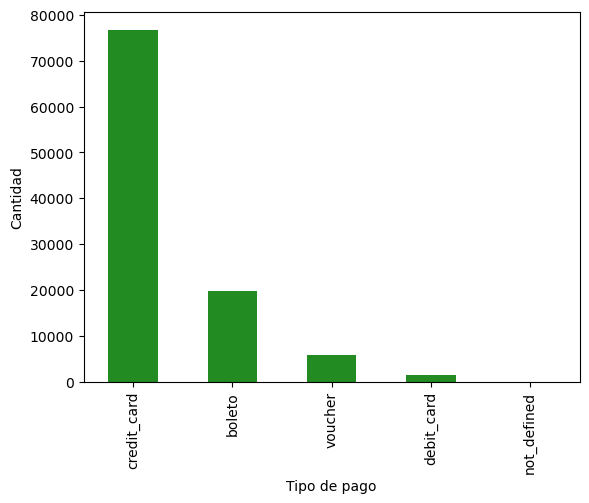

In [79]:
tipo_pago.plot(x = "payment_type", y = "count", kind = "bar", 
               xlabel = "Tipo de pago", ylabel = "Cantidad", 
               legend = False, color = "forestgreen")

In [80]:
tipo_pago

,payment_type,count
0,credit_card,76795
1,boleto,19784
2,voucher,5775
3,debit_card,1529
4,not_defined,3


<Axes: >

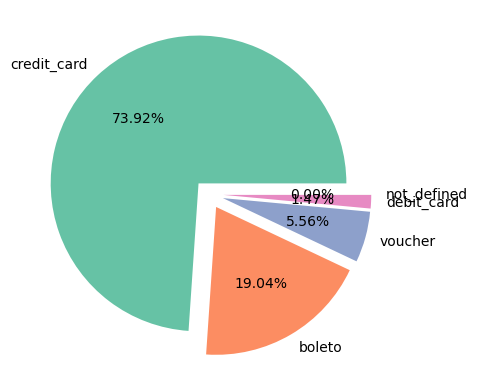

In [81]:
tipo_pago.plot(labels = tipo_pago["payment_type"].values, y = "count", kind = "pie", 
               legend = False, autopct = "%1.2f%%", 
               ylabel = "", 
               colors = sns.color_palette("Set2"),
               explode = [0.1, 0.1, 0.1, 0.1, 0.1])

6. ¿Cuánto se gastó en promedio por tipo de producto? 

In [82]:
ventas2 = ventas.merge(productos2, how = "left", on = 'product_id')
precio_promedio = ventas2.groupby('product_category_name_english')['price'].mean().reset_index() \
    .sort_values("price", ascending = False)

<Axes: xlabel='product_category_name_english'>

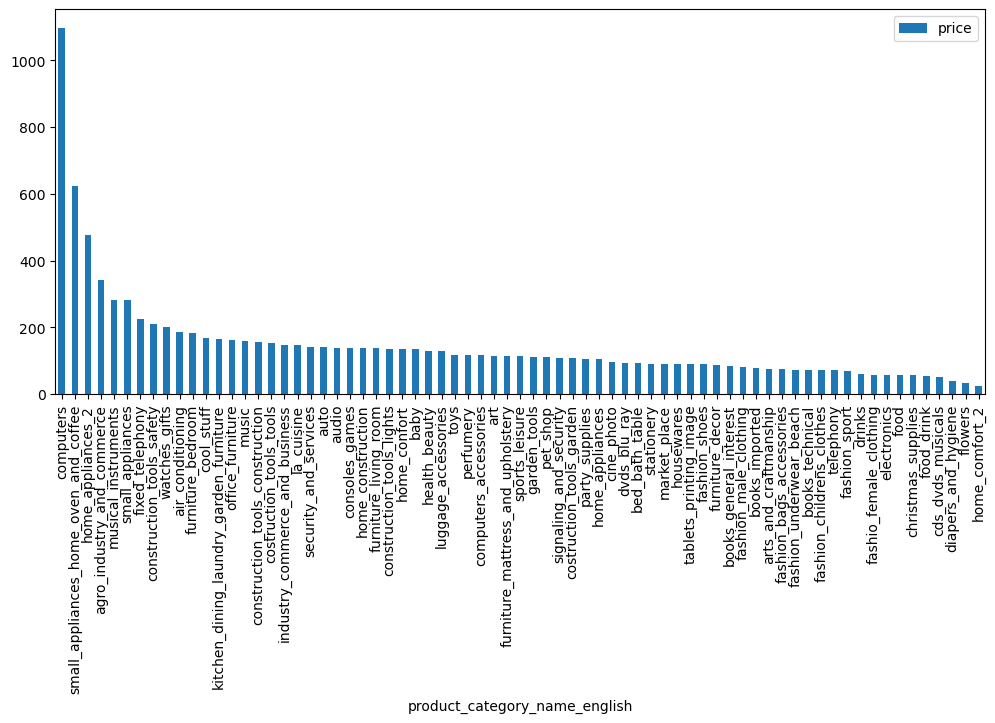

In [83]:
precio_promedio.plot(x = "product_category_name_english", y = "price", kind = "bar",
                     figsize = (12, 5))

¿Cómo funciona `plt.subplots()`?

En la línea de código `fig, ax = plt.subplots()`, `fig` y `ax` son dos variables que se utilizan para almacenar los objetos de figura y ejes devueltos por la función `plt.subplots()`, respectivamente.

La variable `fig` almacena el objeto de figura que representa toda la ventana o lienzo de la gráfica, mientras que la variable `ax` almacena el objeto de ejes que representa una región rectangular dentro de la `figura donde los gráficos se trazan.

Es importante tener en cuenta que la función `plt.subplots()` devuelve dos valores, una figura y un arreglo de ejes. El arreglo de ejes es una matriz de objetos de ejes, y su tamaño está determinado por el número de filas y columnas especificados como argumentos en la función `plt.subplots()`. Si no se especifican estos argumentos, se utiliza un valor predeterminado de una sola fila y una sola columna.

Una vez que se han almacenado los objetos de figura y ejes en las variables `fig` y `ax`, respectivamente, podemos usarlos para personalizar la figura y agregar diferentes tipos de gráficos en el conjunto de ejes. Por ejemplo, podemos cambiar el tamaño de la figura, agregar títulos y etiquetas de eje, cambiar los colores y estilos de las líneas, y mucho más.

In [84]:
import matplotlib.pyplot as plt
import numpy as np

In [85]:
# Generar algunos datos de ejemplo
x = np.linspace(0, 2*np.pi, 100)
x

array([0.        , 0.06346652, 0.12693304, 0.19039955, 0.25386607,
       0.31733259, 0.38079911, 0.44426563, 0.50773215, 0.57119866,
       0.63466518, 0.6981317 , 0.76159822, 0.82506474, 0.88853126,
       0.95199777, 1.01546429, 1.07893081, 1.14239733, 1.20586385,
       1.26933037, 1.33279688, 1.3962634 , 1.45972992, 1.52319644,
       1.58666296, 1.65012947, 1.71359599, 1.77706251, 1.84052903,
       1.90399555, 1.96746207, 2.03092858, 2.0943951 , 2.15786162,
       2.22132814, 2.28479466, 2.34826118, 2.41172769, 2.47519421,
       2.53866073, 2.60212725, 2.66559377, 2.72906028, 2.7925268 ,
       2.85599332, 2.91945984, 2.98292636, 3.04639288, 3.10985939,
       3.17332591, 3.23679243, 3.30025895, 3.36372547, 3.42719199,
       3.4906585 , 3.55412502, 3.61759154, 3.68105806, 3.74452458,
       3.8079911 , 3.87145761, 3.93492413, 3.99839065, 4.06185717,
       4.12532369, 4.1887902 , 4.25225672, 4.31572324, 4.37918976,
       4.44265628, 4.5061228 , 4.56958931, 4.63305583, 4.69652

In [86]:
y1 = np.sin(x)
y2 = np.cos(x)

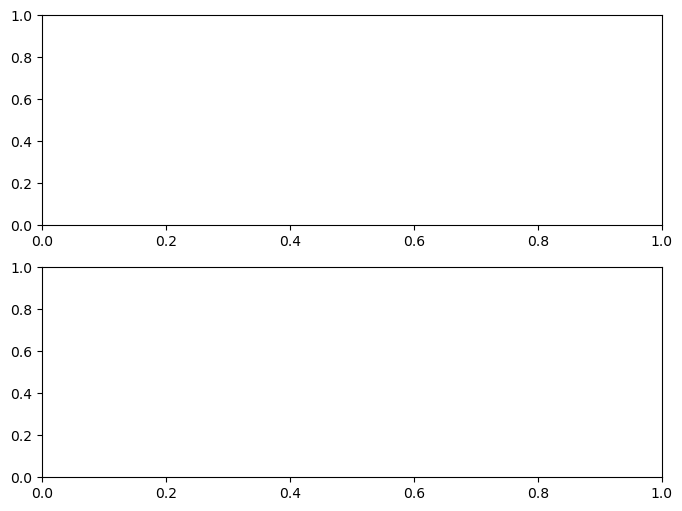

In [87]:
# Crear una figura y dos conjuntos de ejes
fig, ax = plt.subplots(nrows = 2, ncols = 1, figsize = (8, 6))

In [88]:
# Graficar la función seno en el primer conjunto de ejes
ax[0].plot(x, y1, color = 'blue', label = 'Seno')
ax[0].set_title('Conjunto de ejes 1')
ax[0].legend()

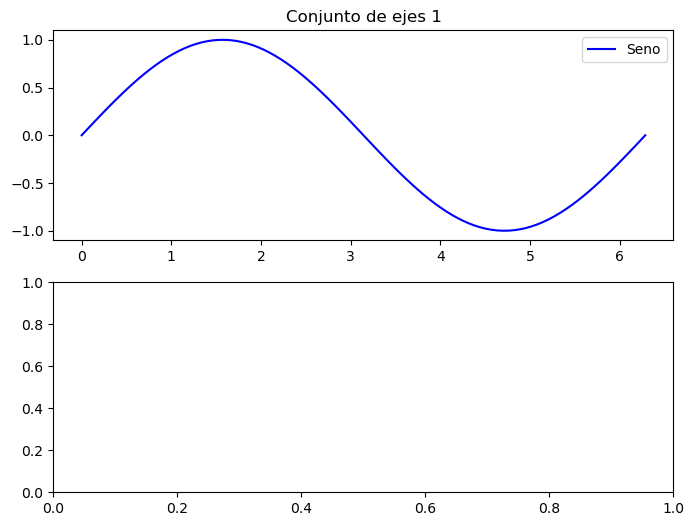

In [89]:
fig

In [90]:
# Graficar la función coseno en el segundo conjunto de ejes
ax[1].plot(x, y2, color = 'red', label=  'Coseno')
ax[1].set_title('Conjunto de ejes 2')
ax[1].legend()

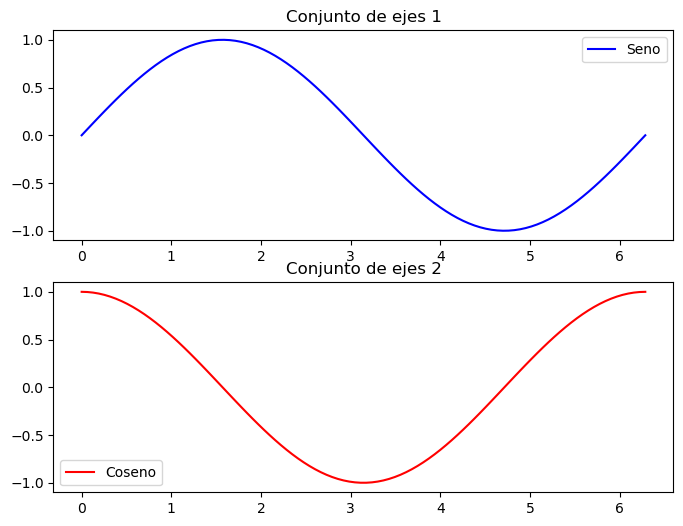

In [91]:
fig

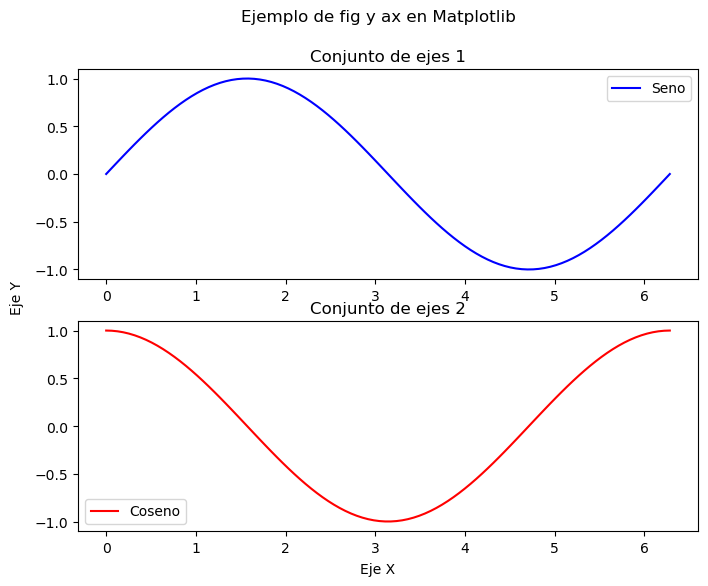

In [92]:
# Agregar título y etiquetas de eje a la figura
fig.suptitle('Ejemplo de fig y ax en Matplotlib')
fig.text(0.5, 0.04, 'Eje X', ha = 'center')
fig.text(0.04, 0.5, 'Eje Y', va = 'center', rotation = 'vertical')

# Mostrar la figura
fig

Text(0.5, 1.0, 'Precio promedio por categoría')

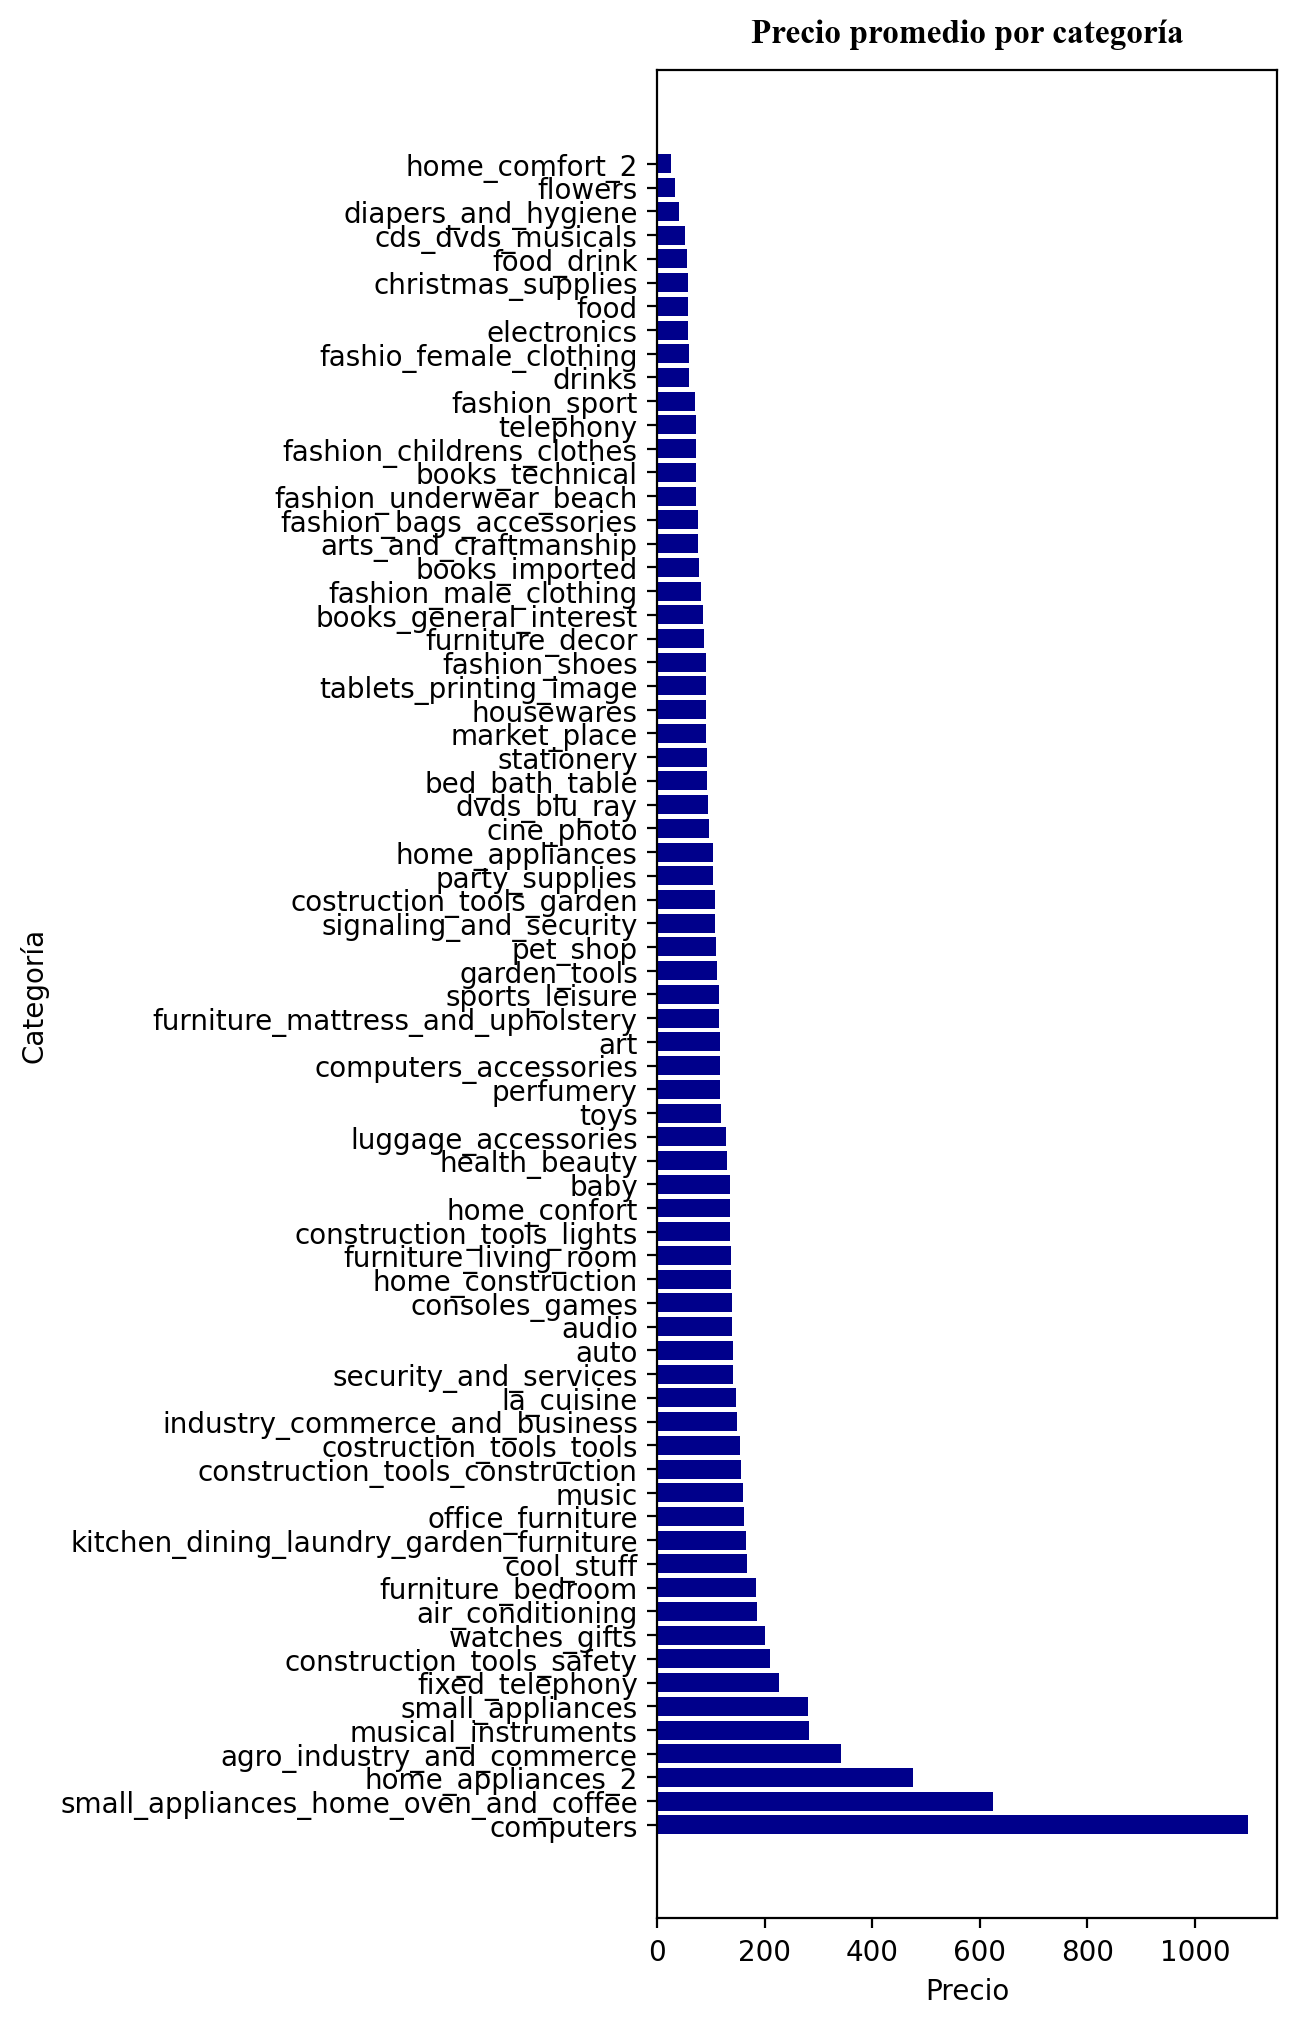

In [93]:
fig, ax = plt.subplots(figsize = (4, 12), dpi = 200)
ax.barh(width = precio_promedio["price"], y = precio_promedio["product_category_name_english"], color = "darkblue")
ax.set_xlabel("Precio") # plt.xlabel("Precio")
ax.set_ylabel("Categoría") # plt.ylabel("Categoría")
ax.set_title("Precio promedio por categoría", fontsize = 12, pad = 10, 
             fontname = "Times New Roman", fontweight = "bold") # plt.title()

7. ¿Cómo se distribuye el volumen de ventas por tipo de producto?

In [94]:
# Cantidad de ventas por productos
cantidades_productos = ventas2.groupby('product_category_name_english').size().reset_index(name = "Cantidad")
cantidades_productos = cantidades_productos.sort_values("Cantidad", ascending = False)

Text(0.5, 1.0, 'Número de productos vendidos por categoría')

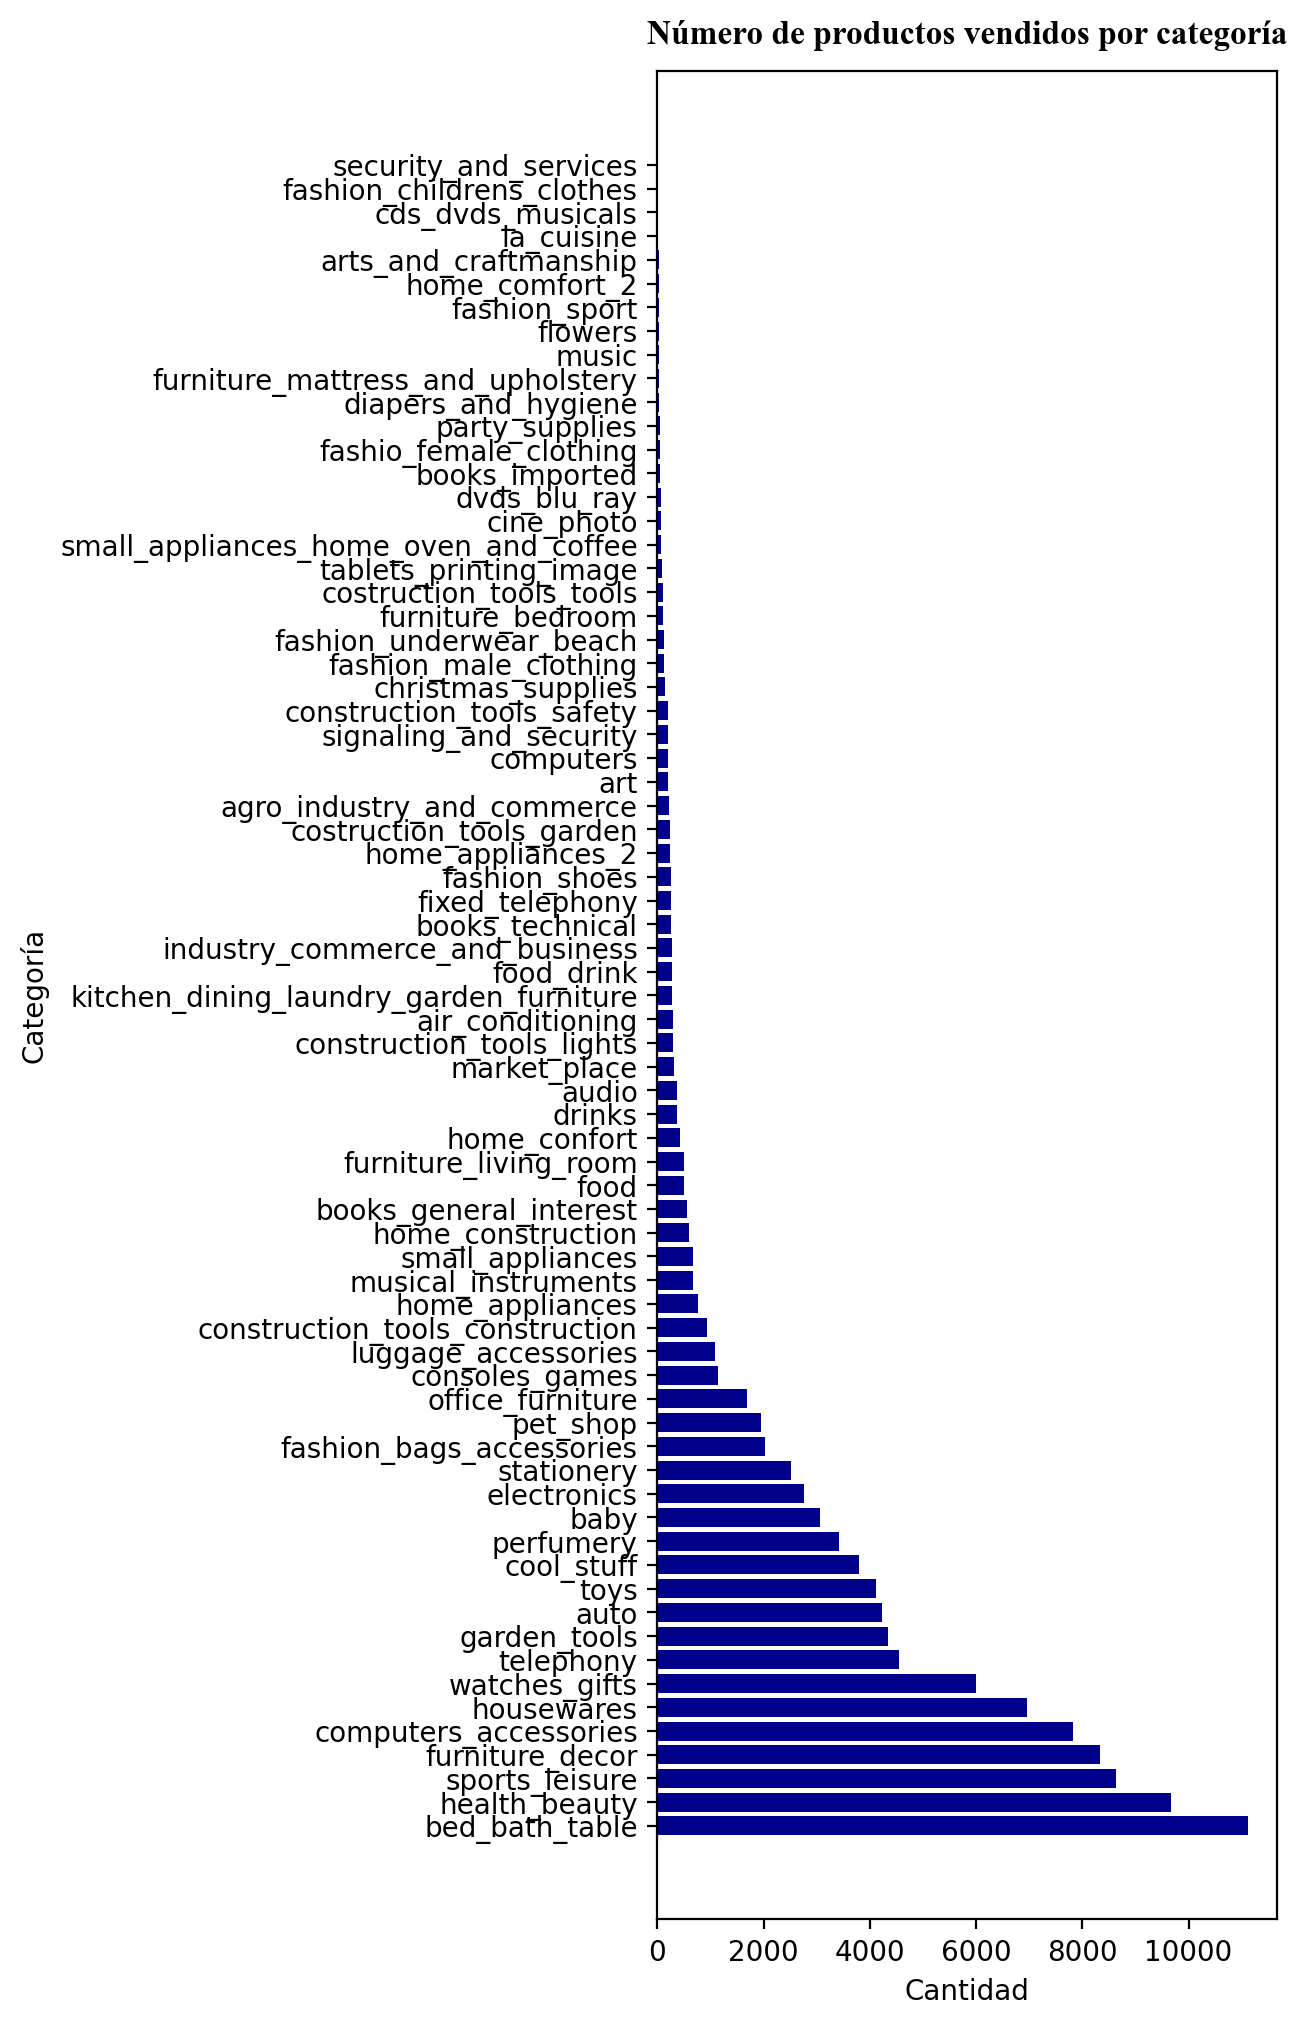

In [95]:
fig, ax = plt.subplots(figsize = (4, 12), dpi = 200)
ax.barh(width = cantidades_productos["Cantidad"], y = cantidades_productos["product_category_name_english"], 
        color = "darkblue")
plt.xlabel("Cantidad")
plt.ylabel("Categoría")
plt.title("Número de productos vendidos por categoría", fontsize = 12, pad = 10, 
          fontname = "Times New Roman", fontweight = "bold")

8. Construya la serie de tiempo de las ventas diarias

In [96]:
ventas3 = ventas2.merge(entregas, on = 'order_id', how = "left")

In [97]:
# Creamos la variable fecha de compra
ventas3["order_purchase_timestamp"] = pd.to_datetime(ventas3["order_purchase_timestamp"]) 
ventas3["order_purchase_timestamp"].head()

0   2017-09-13 08:59:02
1   2017-04-26 10:53:06
2   2018-01-14 14:33:31
3   2018-08-08 10:00:35
4   2017-02-04 13:57:51
Name: order_purchase_timestamp, dtype: datetime64[ns]

In [98]:
ventas3["fechas_compra"] = ventas3["order_purchase_timestamp"].dt.date
ventas3["fechas_compra"].head()

0    2017-09-13
1    2017-04-26
2    2018-01-14
3    2018-08-08
4    2017-02-04
Name: fechas_compra, dtype: object

In [99]:
# Número de ventas por día
serie_compras = ventas3.groupby('fechas_compra').size().reset_index(name = "n")
serie_compras.head()

,fechas_compra,n
0,2016-09-04,2
1,2016-09-05,1
2,2016-09-15,3
3,2016-10-02,1
4,2016-10-03,8


<Axes: xlabel='fechas_compra'>

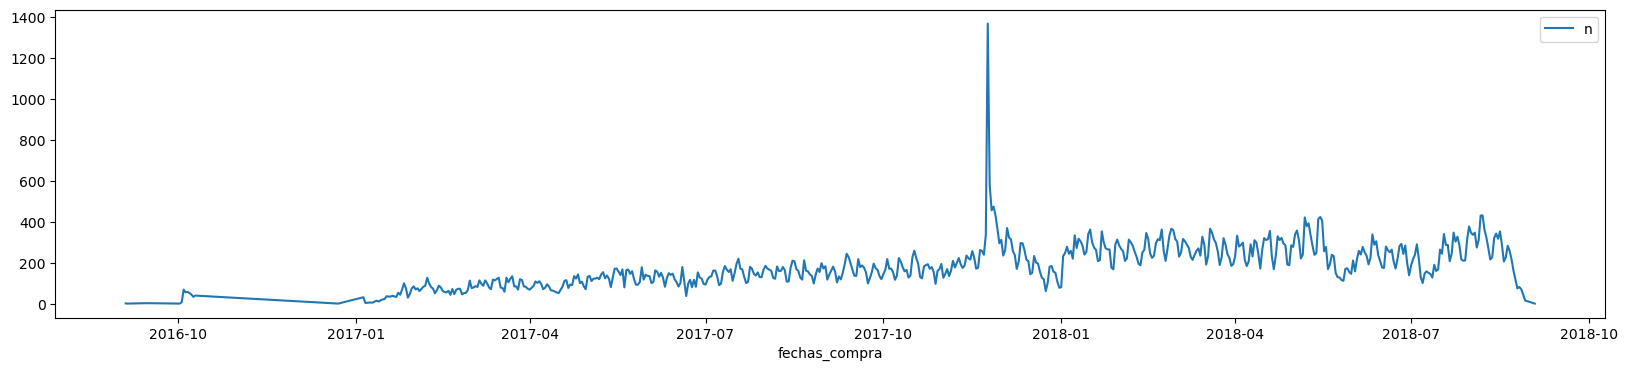

In [100]:
serie_compras.plot(x = "fechas_compra", y = "n", figsize = (20, 4))

Ahora vamos a analizar como se correlaciona la serie con sus rezagos:

In [101]:
serie_compras.head()

,fechas_compra,n
0,2016-09-04,2
1,2016-09-05,1
2,2016-09-15,3
3,2016-10-02,1
4,2016-10-03,8


In [102]:
# Rezago (lag) de 1
serie_compras["n"].shift(1)

0       NaN
1       2.0
2       1.0
3       3.0
4       1.0
       ... 
611    75.0
612    82.0
613    71.0
614    45.0
615    16.0
Name: n, Length: 616, dtype: float64

In [103]:
# Rezago (lag) de 2
serie_compras["n"].shift(2)

0        NaN
1        NaN
2        2.0
3        1.0
4        3.0
       ...  
611    117.0
612     75.0
613     82.0
614     71.0
615     45.0
Name: n, Length: 616, dtype: float64

In [104]:
# Hacia adelante (lead) de 1
serie_compras["n"].shift(-1)

0       1.0
1       3.0
2       1.0
3       8.0
4      69.0
       ... 
611    71.0
612    45.0
613    16.0
614     1.0
615     NaN
Name: n, Length: 616, dtype: float64

In [105]:
# Hacia adelante (lead) de 2
serie_compras["n"].shift(-2)

0       3.0
1       1.0
2       8.0
3      69.0
4      56.0
       ... 
611    45.0
612    16.0
613     1.0
614     NaN
615     NaN
Name: n, Length: 616, dtype: float64

Vamos a utilizar la función `np.corrcoef()` para calcular la correlación entre la serie y sus rezagos:

$$\rho_{X,Y} = \frac{\sigma_{XY}}{\sigma_X \sigma_Y} = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum (x_i - \bar{x})^2}\sqrt{\sum (y_i - \bar{y})^2}}.$$

In [106]:
# Correlación del numero de ventas diarias con su serie rezagada 1, 2, ... 30, días 
correlaciones = []
for i in range(1,31):   
    # Ojo. Cuando creamos los rezagos, tenemos NAs (no sabemos que hay antes de la primera observación)
    # Luego, es necesario no tener en cuenta los períodos faltantes en el cálculo de la correlación 
    X = serie_compras["n"][i:]
    Y = serie_compras["n"].shift(i)[i:]
    corr = np.corrcoef(X, Y)
    corr = corr[1,0]
    correlaciones.append(corr) 

Note que en la medida que aumenta el rezago, se disminuye la correlación, sin embargo, hay un patrón en el que rezagos múltiplos de 7 tienen una correlación superior a la esperada. Esto señala que nuestra serie tiene un efecto semanal, las ventas se pueden explicar en gran medida por el día de la semana.

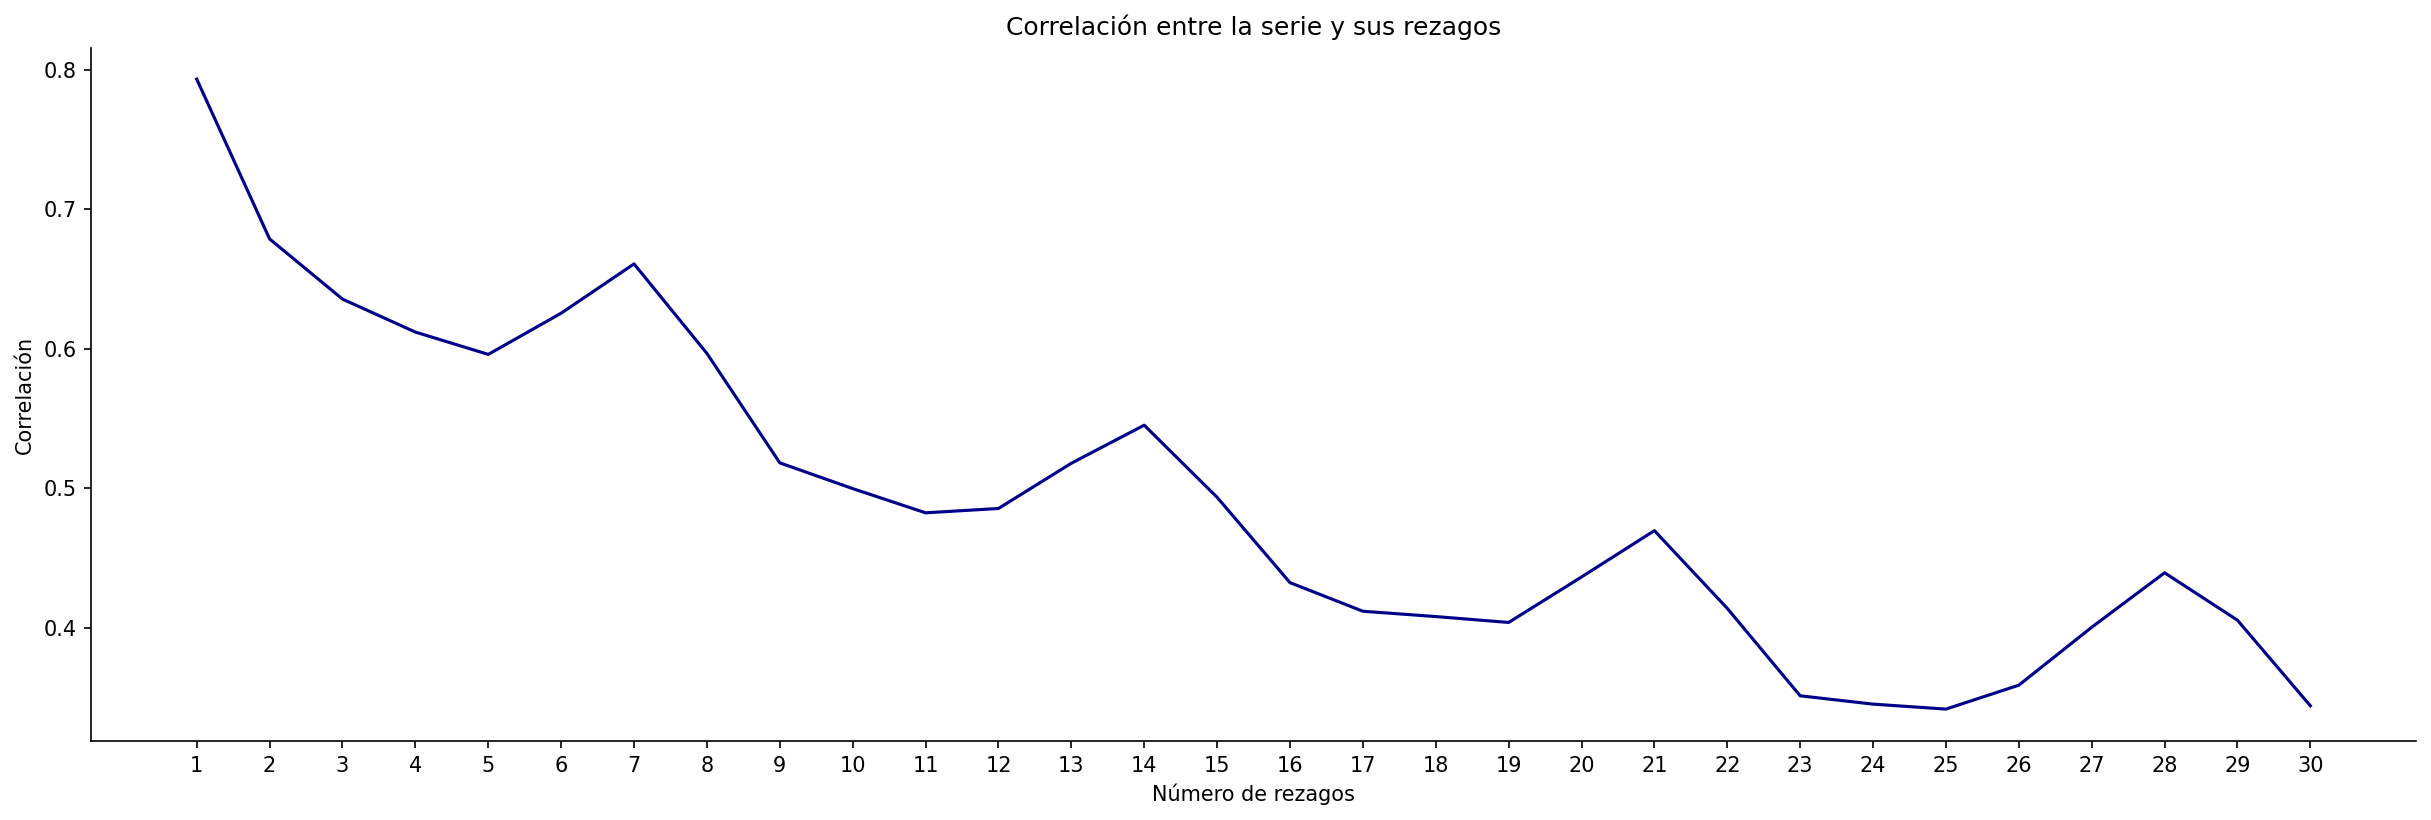

In [107]:
fig, ax = plt.subplots(figsize = (20,6), dpi = 150)
sns.despine()
plt.plot(range(1,31), correlaciones, color = "darkblue")
plt.xticks(range(1,31),range(1,31));
plt.title("Correlación entre la serie y sus rezagos");
plt.xlabel("Número de rezagos");
plt.ylabel("Correlación");

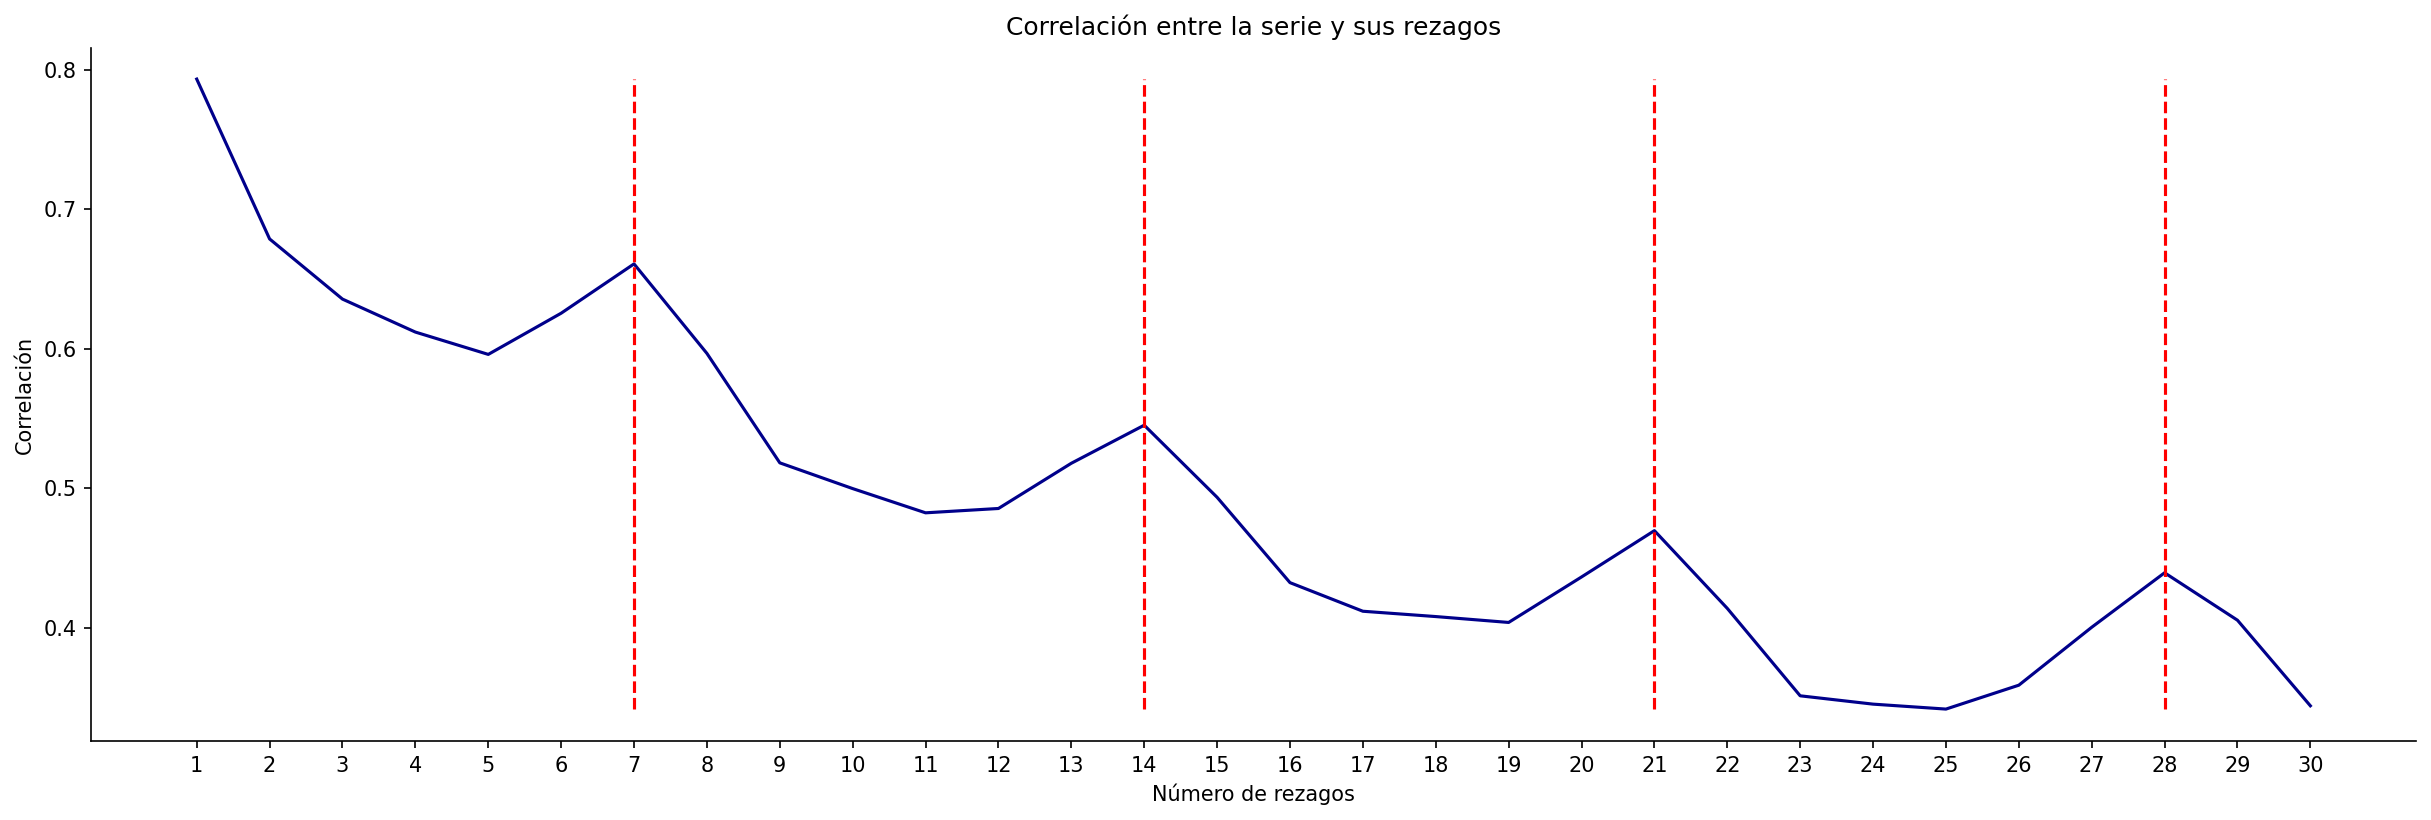

In [108]:
fig, ax = plt.subplots(figsize = (20,6), dpi = 150)
sns.despine()
plt.plot(range(1,31), correlaciones, color = "darkblue")
plt.xticks(range(1,31),range(1,31));
plt.title("Correlación entre la serie y sus rezagos");
plt.xlabel("Número de rezagos");
plt.ylabel("Correlación");
# Pintamos lineas verticales en rojo desde 7 hasta 31 dando saltos de 7 unidades.
plt.vlines(range(7, 31, 7), min(correlaciones), max(correlaciones), colors = 'red', linestyles = "dashed");

Vamos a construir la serie rezagada 7 días para analizar su comportamiento

In [109]:
# Rezagamos la serie 7 días (una semana)
serie_compras["n_l7"] = serie_compras["n"].shift(-7)

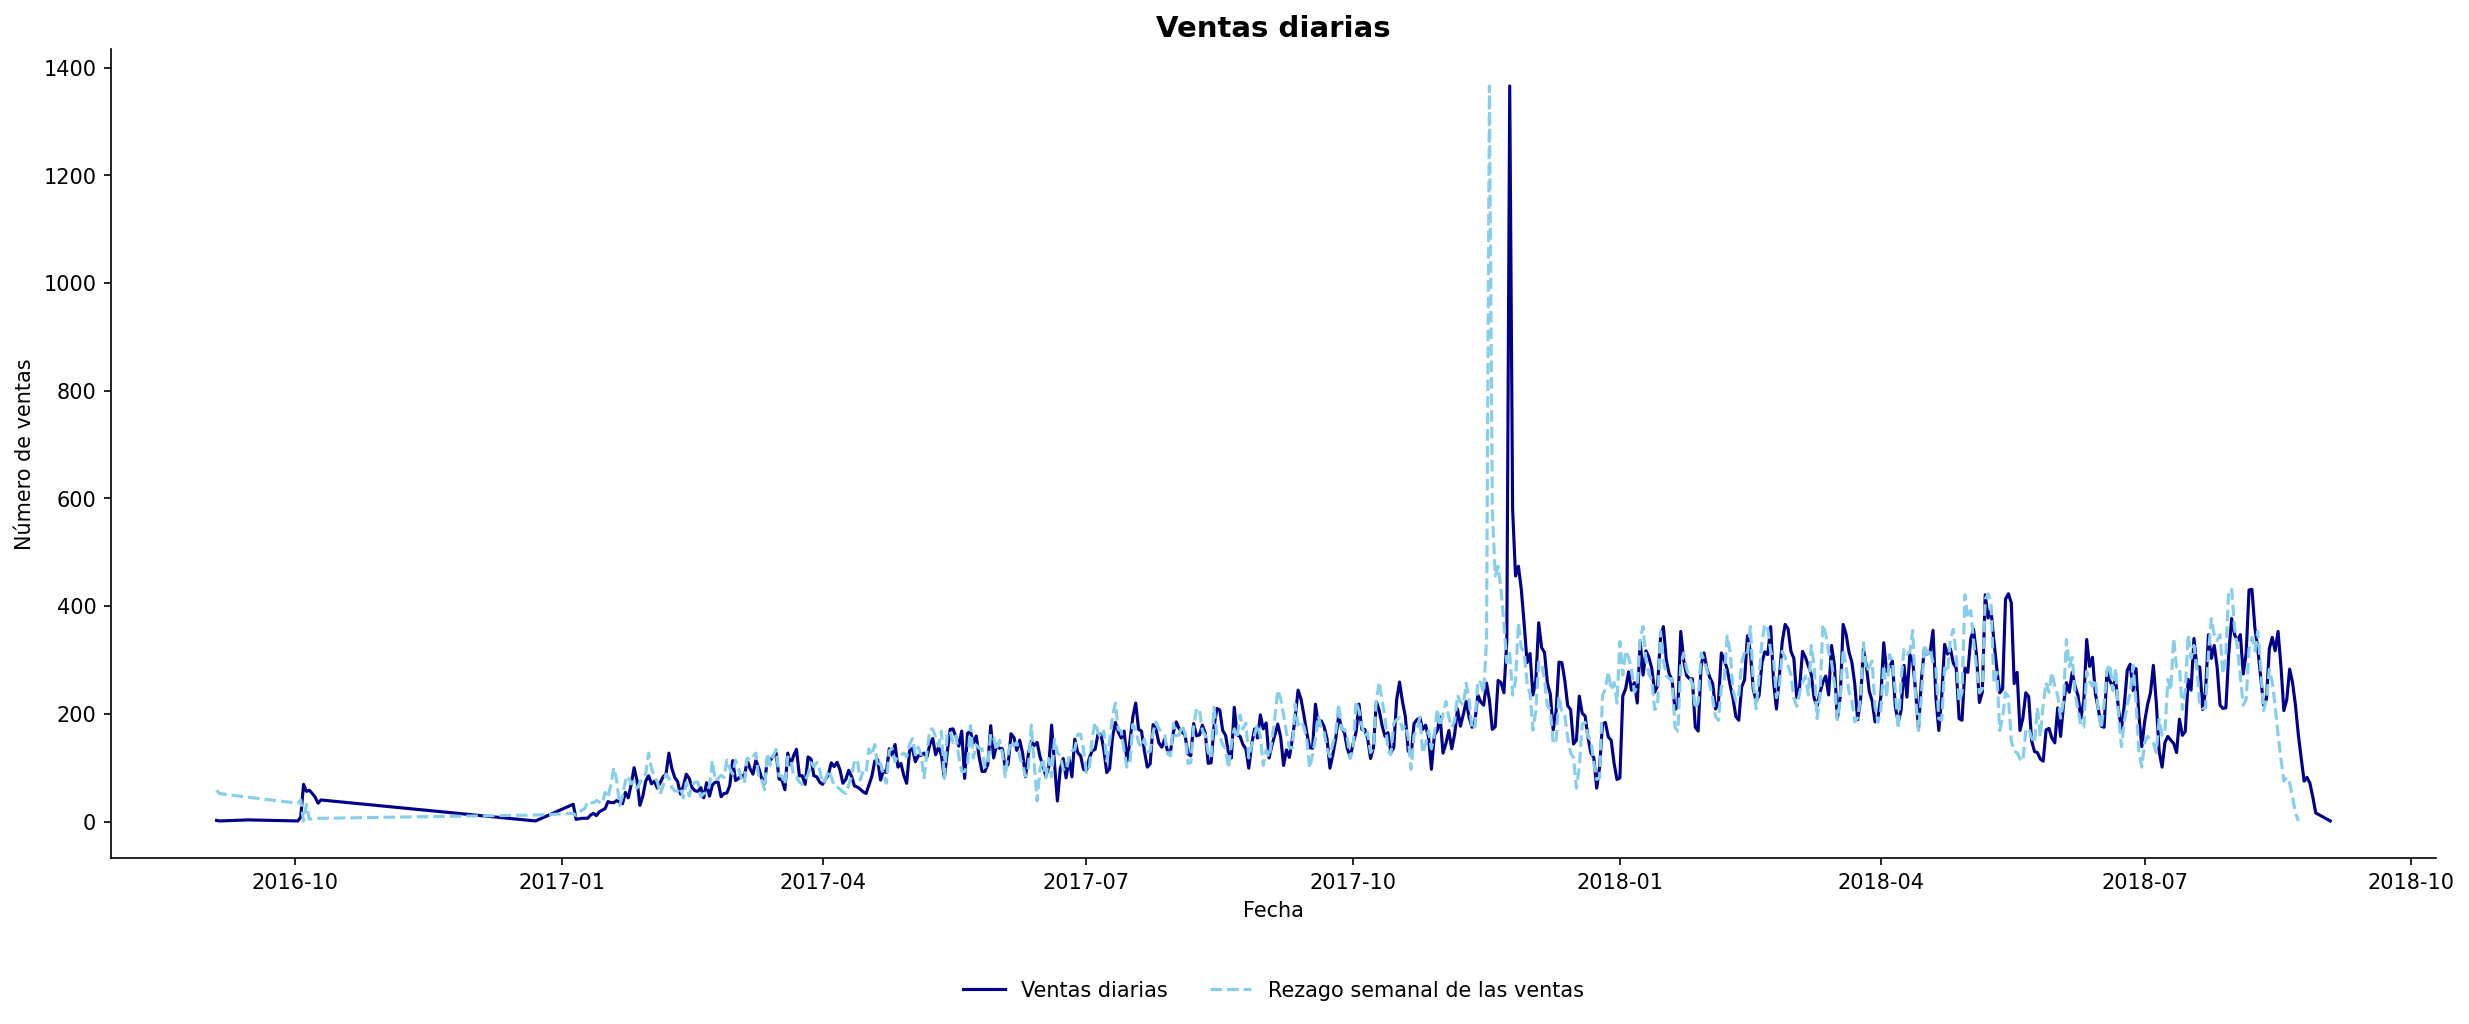

In [110]:
fig, ax = plt.subplots(figsize = (20, 7), dpi = 150)
sns.despine()
plt.plot(serie_compras["fechas_compra"], serie_compras["n"], color = "darkblue")
plt.plot(serie_compras["fechas_compra"], serie_compras["n_l7"], color = "skyblue", linestyle = "dashed")
plt.legend(['Ventas diarias', 'Rezago semanal de las ventas'], loc = "lower center", 
           bbox_to_anchor = (0.5, -0.2), ncol = 2, frameon = False);
plt.xlabel("Fecha");
plt.ylabel("Número de ventas");
plt.title("Ventas diarias", fontsize = 14, fontweight = "bold");

In [111]:
# Cojamos solo los últimos 3 meses
fecha_maxima = serie_compras["fechas_compra"].max()
fecha_maxima

datetime.date(2018, 9, 3)

In [112]:
from dateutil.relativedelta import *
punto_corte = fecha_maxima - relativedelta(months = 3)
punto_corte

datetime.date(2018, 6, 3)

In [113]:
ultimos_meses = serie_compras.loc[serie_compras["fechas_compra"] >= punto_corte,]
ultimos_meses.head()

,fechas_compra,n,n_l7
527,2018-06-03,217,224.0
528,2018-06-04,258,338.0
529,2018-06-05,240,288.0
530,2018-06-06,277,305.0
531,2018-06-07,251,237.0


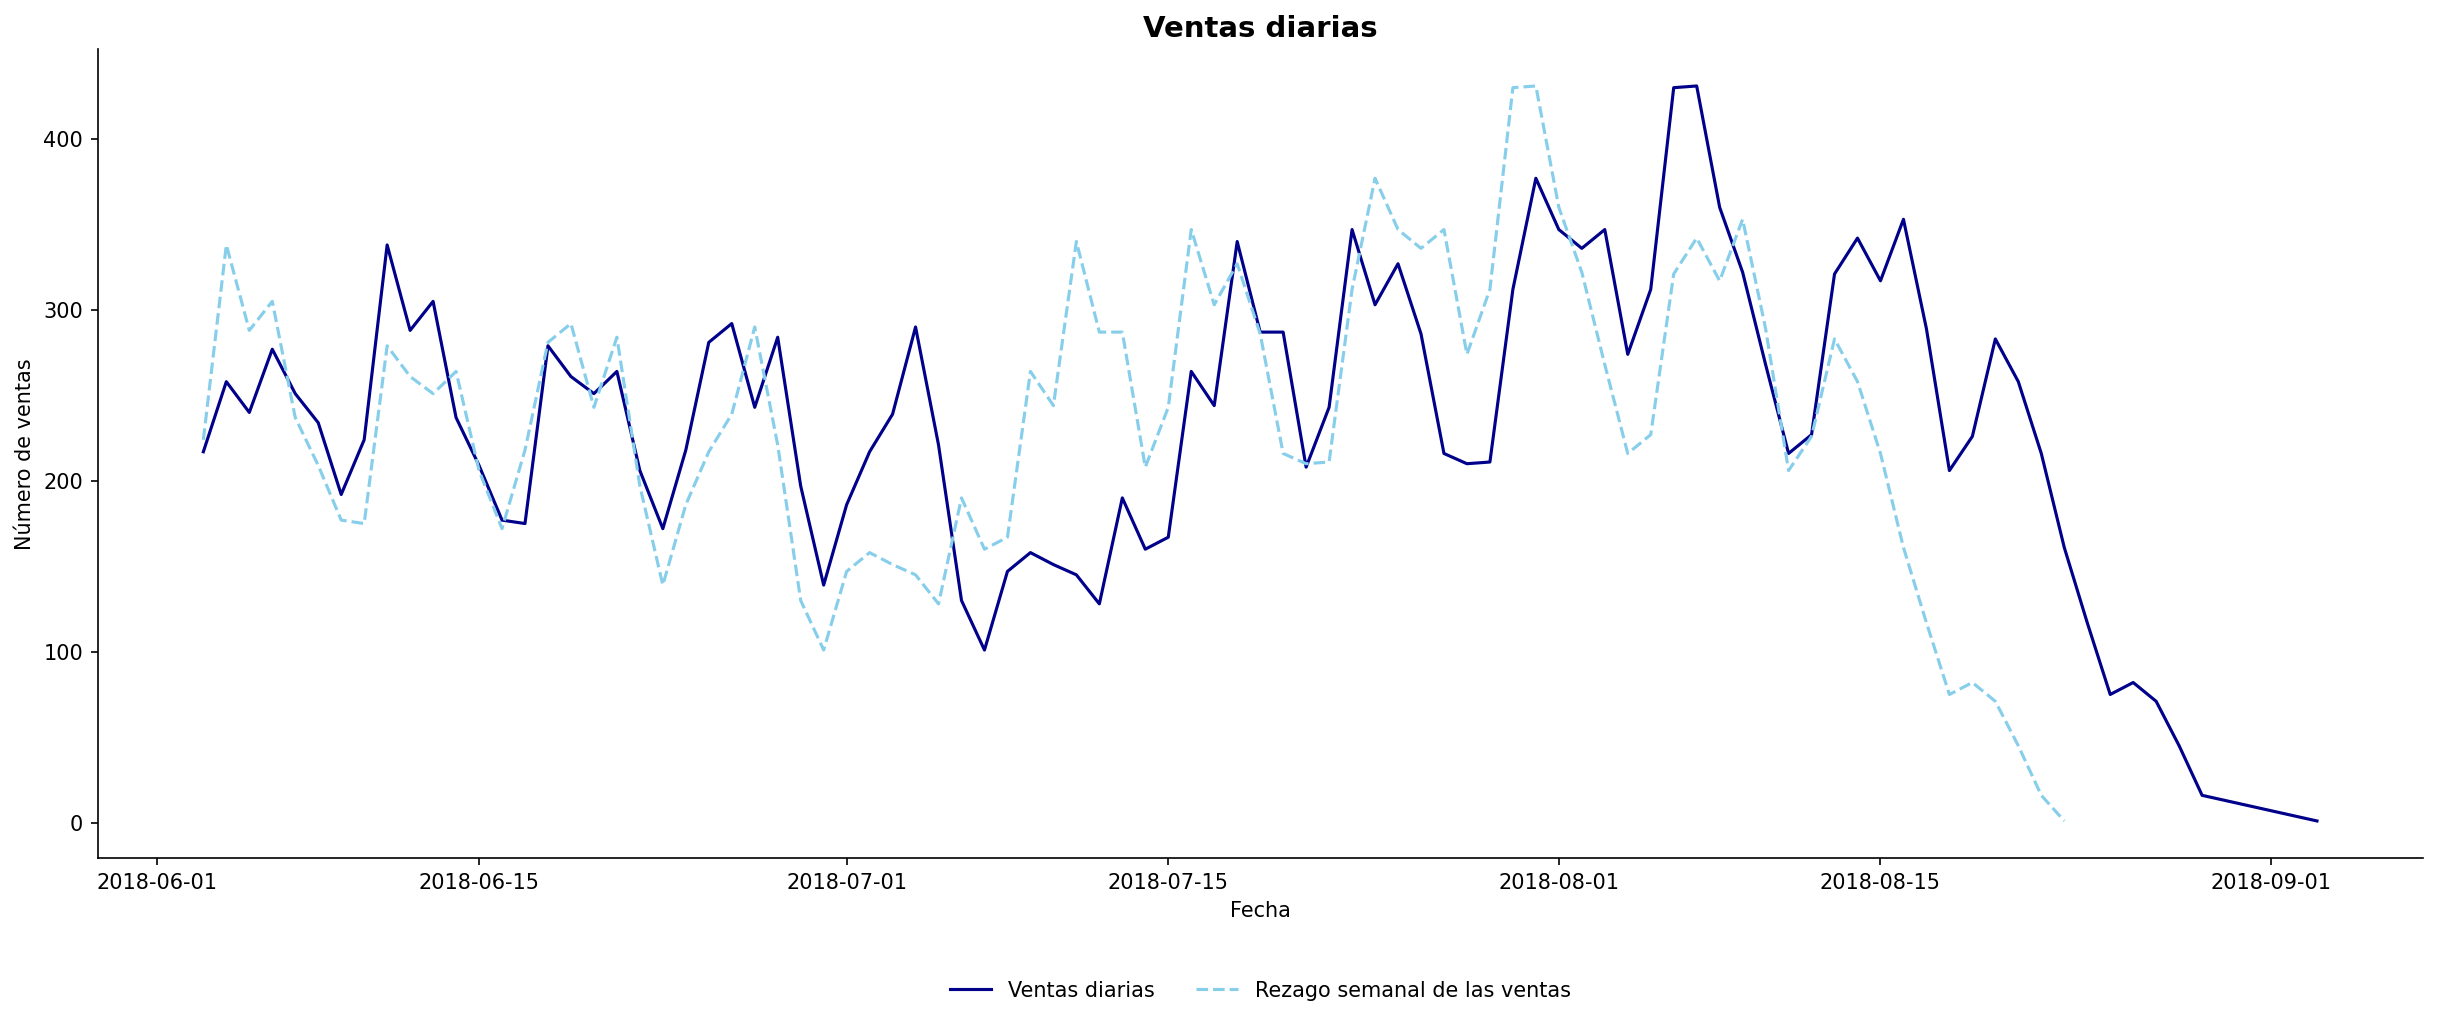

In [114]:
fig, ax = plt.subplots(figsize = (20, 7), dpi = 150)
sns.despine()
plt.plot(ultimos_meses["fechas_compra"], ultimos_meses["n"], color = "darkblue")
plt.plot(ultimos_meses["fechas_compra"], ultimos_meses["n_l7"], color = "skyblue", linestyle = "dashed")
plt.legend(['Ventas diarias', 'Rezago semanal de las ventas'], loc = "lower center", 
           bbox_to_anchor = (0.5, -0.2), ncol = 2, frameon = False);
plt.xlabel("Fecha");
plt.ylabel("Número de ventas");
plt.title("Ventas diarias", fontsize = 14, fontweight = "bold");

Calculemos la diferencia entre el valor real y el rezago

In [115]:
serie_compras["diferencia"] = serie_compras["n"] - serie_compras["n_l7"]

Otra forma de hacerlo

In [116]:
serie_compras["diferencia2"] = serie_compras["n"].diff(7)

In [117]:
serie_compras.tail()

,fechas_compra,n,n_l7,diferencia,diferencia2
611,2018-08-26,82,NaN,NaN,-144.0
612,2018-08-27,71,NaN,NaN,-212.0
613,2018-08-28,45,NaN,NaN,-213.0
614,2018-08-29,16,NaN,NaN,-200.0
615,2018-09-03,1,NaN,NaN,-160.0


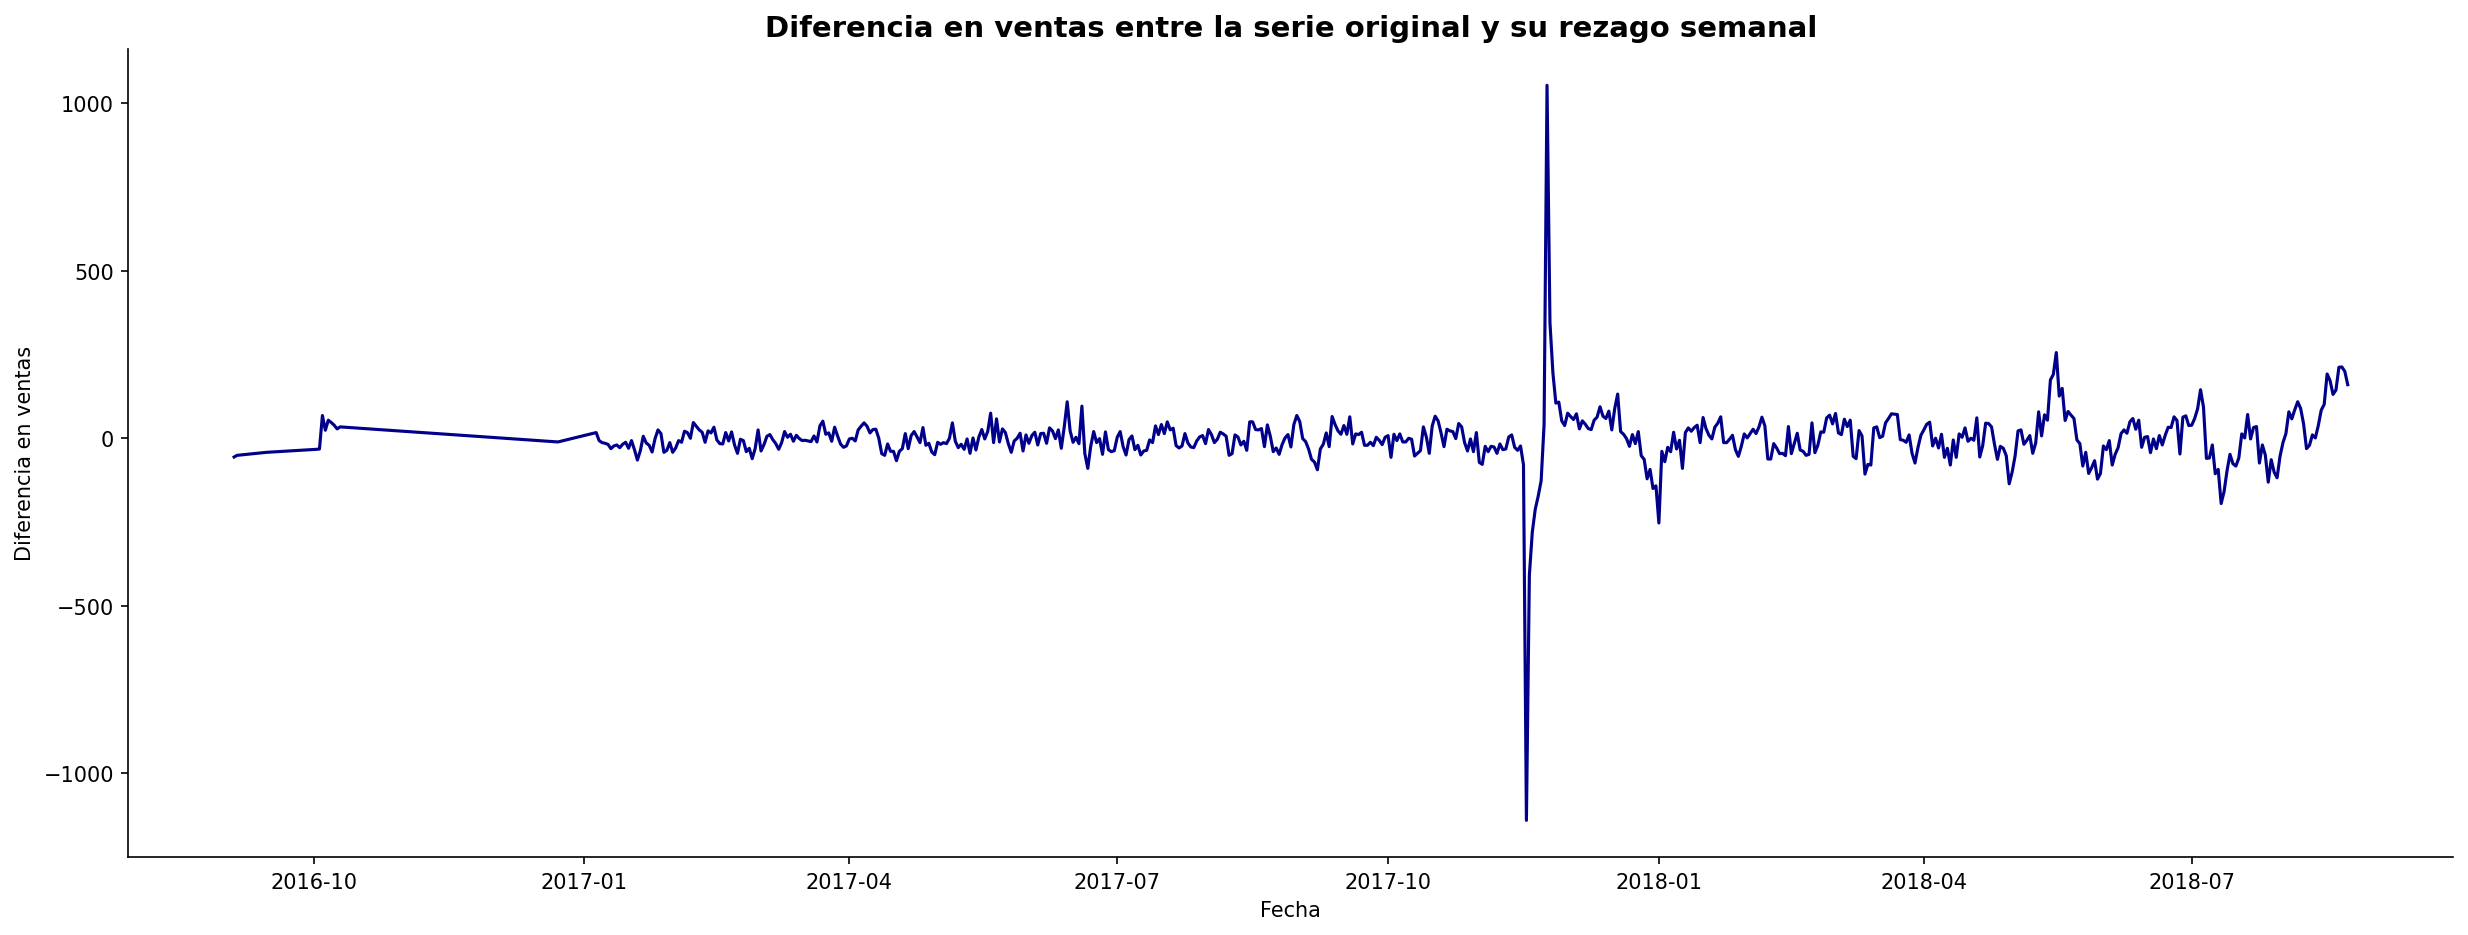

In [118]:
fig, ax = plt.subplots(figsize = (20, 7), dpi = 150)
sns.despine()
plt.plot(serie_compras["fechas_compra"], serie_compras["diferencia"], color = "darkblue")
plt.xlabel("Fecha");
plt.ylabel("Diferencia en ventas");
plt.title("Diferencia en ventas entre la serie original y su rezago semanal", fontsize = 14, fontweight = "bold");

In [119]:
ultimos_meses = serie_compras.loc[serie_compras["fechas_compra"] >= punto_corte,]

Si nos deshacemos del período atípico en general está entre 200 y -200.

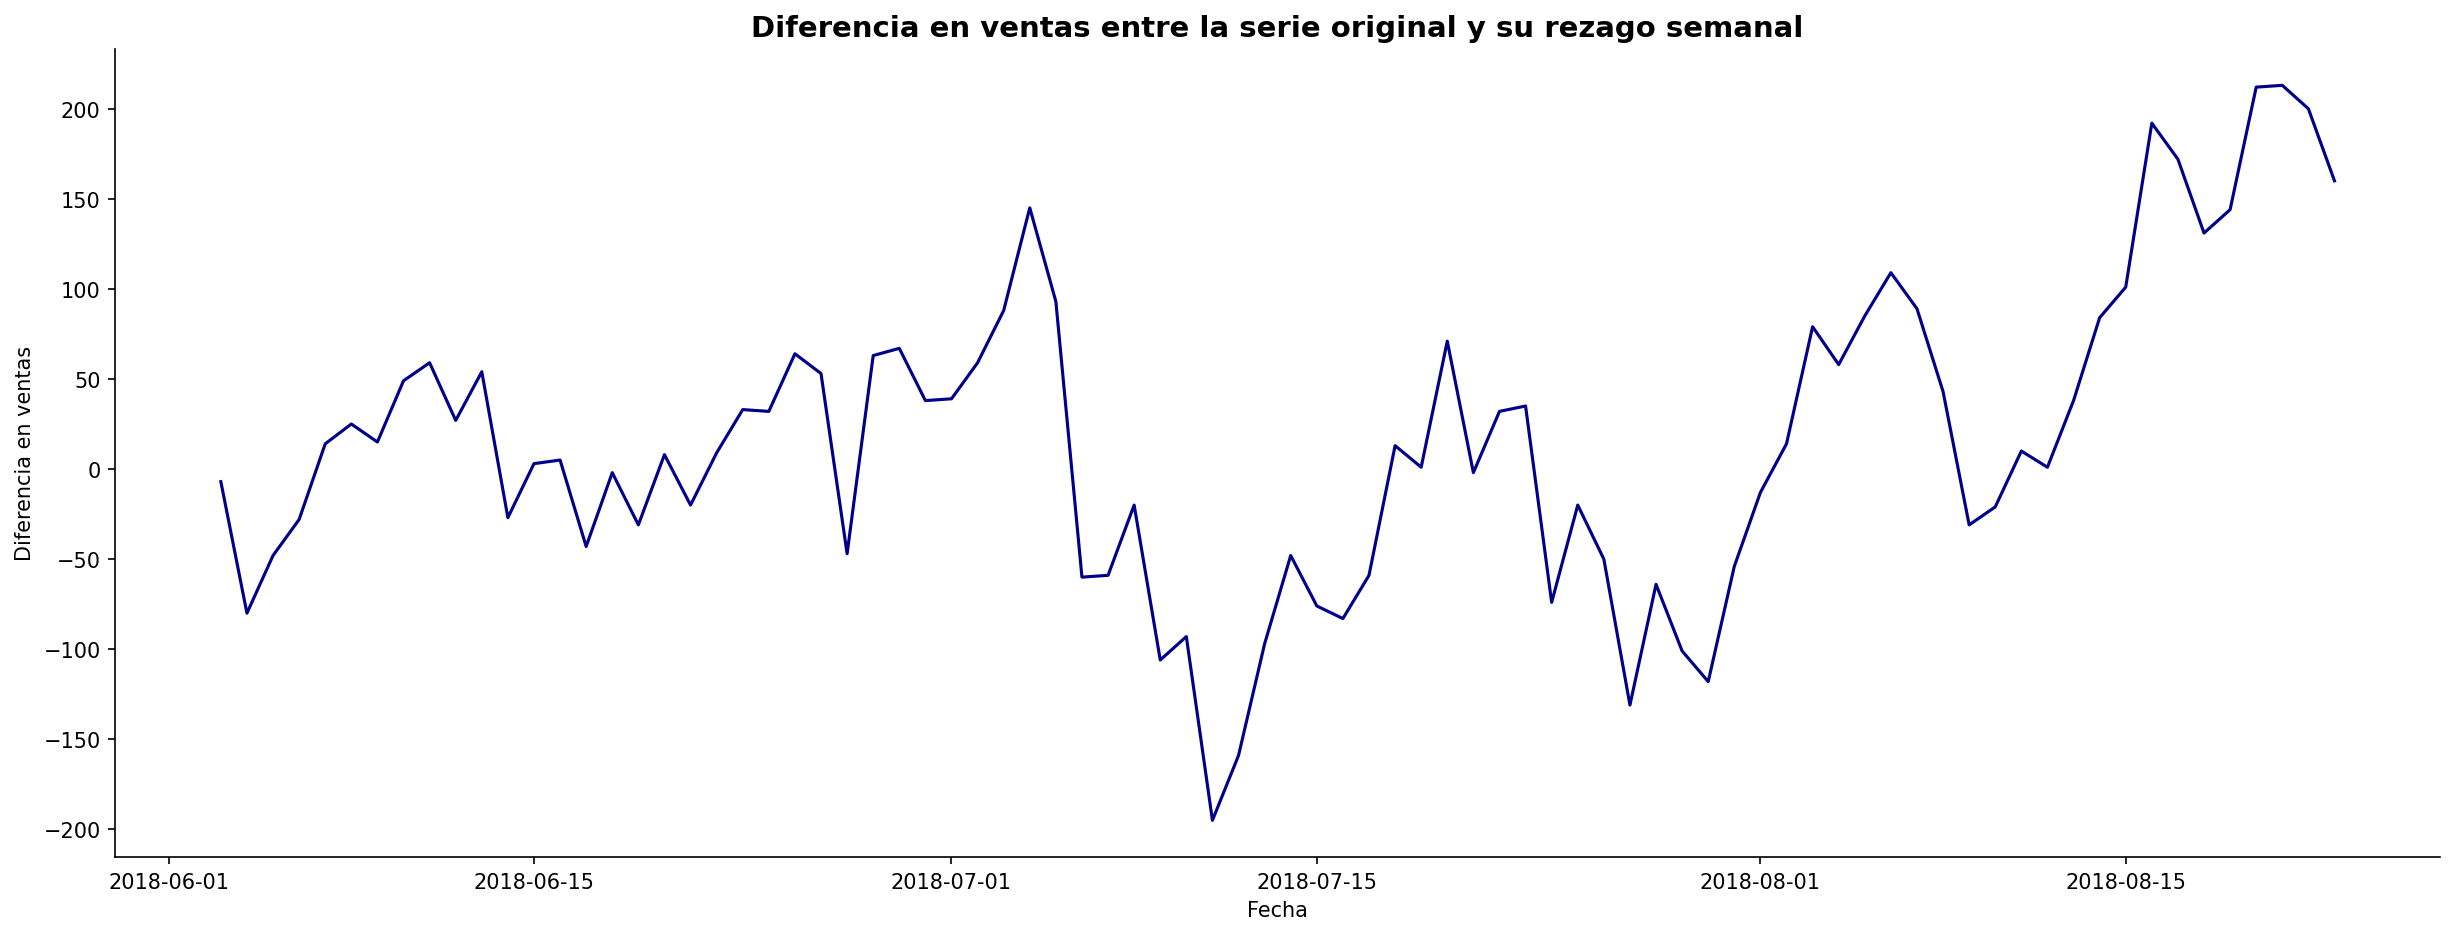

In [120]:
fig, ax = plt.subplots(figsize = (20, 7), dpi = 150)
sns.despine()
plt.plot(ultimos_meses["fechas_compra"], ultimos_meses["diferencia"], color = "darkblue")
plt.xlabel("Fecha");
plt.ylabel("Diferencia en ventas");
plt.title("Diferencia en ventas entre la serie original y su rezago semanal", fontsize = 14, fontweight = "bold");

In [121]:
ultimos_meses["diferencia"].describe()

count     82.000000
mean      15.390244
std       83.911734
min     -195.000000
25%      -46.000000
50%       11.500000
75%       62.000000
max      213.000000
Name: diferencia, dtype: float64

In [122]:
serie_compras["n"].describe()

count     616.000000
mean      182.873377
std       105.888023
min         1.000000
25%       112.000000
50%       169.000000
75%       245.250000
max      1366.000000
Name: n, dtype: float64

9. Convierta la variable de monto de pago a categórica y grafique el número de transacciones en cada categoría creada.

In [123]:
pagos['payment_value'].describe()

count    103886.000000
mean        154.100380
std         217.494064
min           0.000000
25%          56.790000
50%         100.000000
75%         171.837500
max       13664.080000
Name: payment_value, dtype: float64

In [124]:
# pd.cut() nos permite pasar una variable continua a categórica 
pagos['categoria_pago'] = pd.cut(pagos['payment_value'],                           
                                 # Pasamos los limites de los intervalos en los que se divide la variable. 
                                 # También se puede decir el número de grupos en los que se desea dividir: bins = 5.               
                                 bins = [0, 50, 100, 200, 1000, pagos['payment_value'].max()],    
                                 # Los nombres de las categorías creadas. Por ejemplo, la categoría bajo corresponde a 0 < pagos <= 50
                                 labels = ['Bajo', 'Medio-Bajo', 'Medio', 'Medio-Alto', 'Alto'])  

In [125]:
pagos['categoria_pago']

0         Medio-Bajo
1               Bajo
2         Medio-Bajo
3              Medio
4              Medio
             ...    
103881    Medio-Alto
103882    Medio-Bajo
103883          Bajo
103884    Medio-Alto
103885         Medio
Name: categoria_pago, Length: 103886, dtype: category
Categories (5, object): ['Bajo' < 'Medio-Bajo' < 'Medio' < 'Medio-Alto' < 'Alto']

/var/folders/yz/w0xwt9gn5zq7ss8mg0n8hr9h0000gp/T/ipykernel_4676/423279917.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = pagos, x = 'categoria_pago', palette = "RdYlGn", ax = ax)


Text(0, 0.5, 'Cantidad')

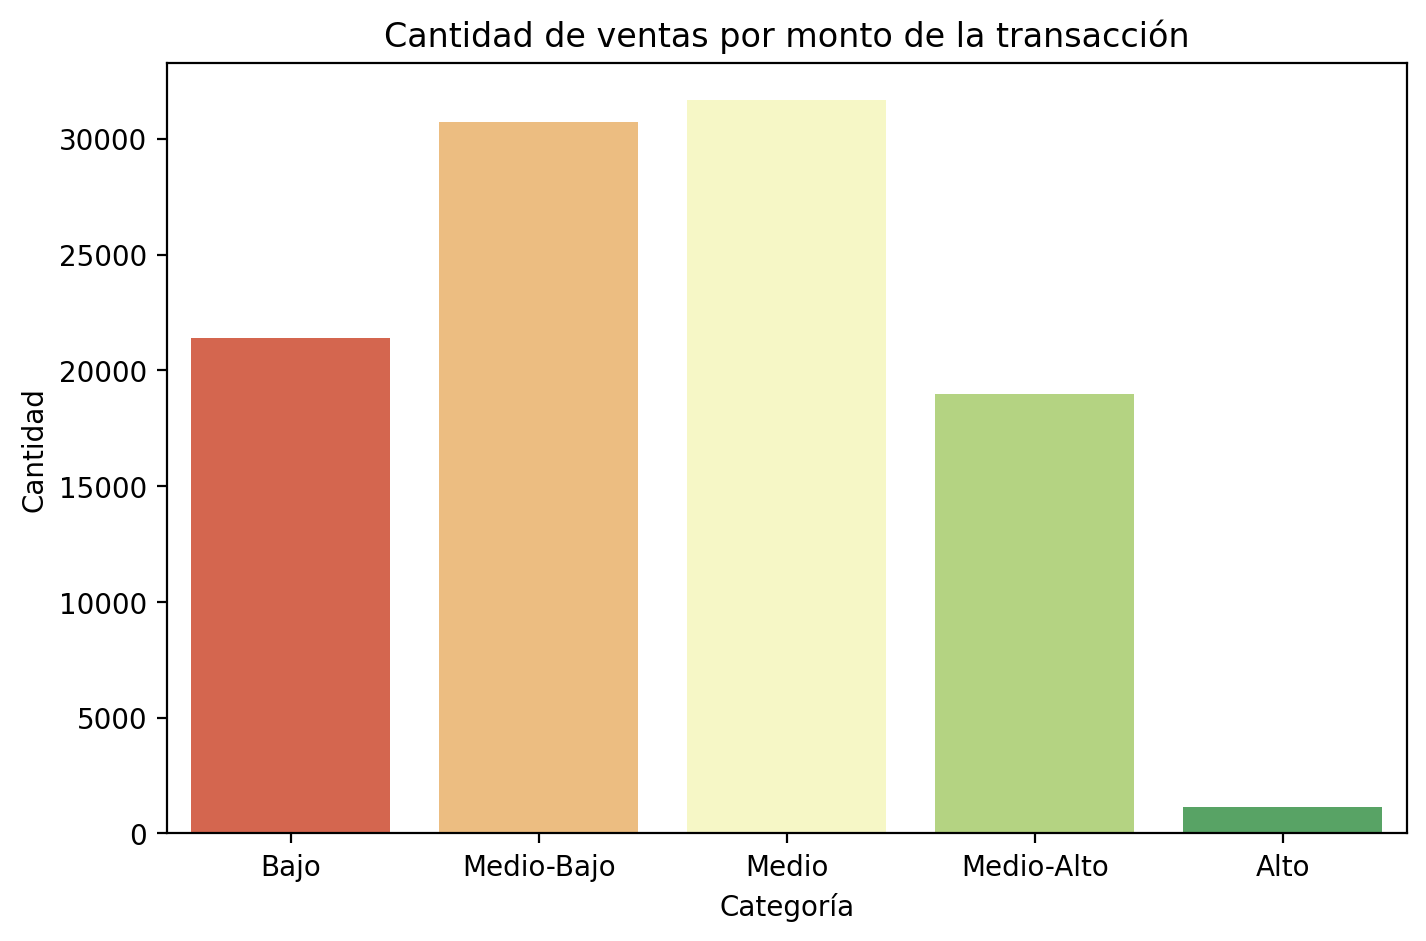

In [126]:
# Gráfico con seaborn que cuenta cuantas veces aparece cada categoría.
fig, ax = plt.subplots(figsize = (8, 5), dpi = 200)
sns.countplot(data = pagos, x = 'categoria_pago', palette = "RdYlGn", ax = ax) 
plt.title("Cantidad de ventas por monto de la transacción")
plt.xlabel("Categoría")
plt.ylabel("Cantidad")